# Prediksi Harga Saham
Prediksi harga saham merupakan salah satu tantangan menarik dalam dunia machine learning karena melibatkan data deret waktu yang kompleks, penuh fluktuasi, dan dipengaruhi berbagai faktor eksternal. Dalam proyek ini, dilakukan eksplorasi beberapa pendekatan deep learning untuk memprediksi harga penutupan saham berdasarkan data historis. Model yang digunakan mencakup Multi-Layer Perceptron (MLP) sebagai baseline, Recurrent Neural Network (RNN) dan Long Short-Term Memory (LSTM) untuk menangkap ketergantungan jangka panjang, serta Convolutional Neural Network (CNN) dan gabungan CNN-LSTM untuk memanfaatkan fitur spasial sekaligus temporal.

Tujuan utama proyek ini adalah membandingkan performa berbagai arsitektur, mengevaluasi akurasi prediksi pada data test, serta menghasilkan prediksi ke depan (forecasting) untuk beberapa hari berikutnya. Melalui pendekatan ini, diharapkan diperoleh gambaran bagaimana masing-masing model merespons pola pasar, serta potensi penerapannya dalam sistem pendukung keputusan investasi.

# Loading & Inspecting Data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import yfinance as yf
from keras import optimizers
from keras.models import Sequential
from keras.layers import Dense, SimpleRNN, Dropout, Input, LSTM, RepeatVector, TimeDistributed, Flatten, BatchNormalization
from tensorflow.keras.layers import Conv1D, MaxPooling1D
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

In [ ]:
# Ambil data Microsoft dari Yahoo Finance
data = yf.download('MSFT', start='1990-12-31', end='2025-08-29', auto_adjust=True)

[*********************100%***********************]  1 of 1 completed


In [ ]:
data.head()

Price,Close,High,Low,Open,Volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT
Date,,,,,
1990-12-31,0.639624,0.639624,0.633249,0.637500,23702400
1991-01-02,0.635374,0.639624,0.635374,0.637499,38109600
1991-01-03,0.639624,0.646000,0.635374,0.635374,52826400
1991-01-04,0.644937,0.650250,0.637500,0.637500,58485600
1991-01-07,0.636437,0.660874,0.635374,0.639624,87552000


In [ ]:
data.columns = data.columns.droplevel(1)
data.columns.name = None
data.reset_index(inplace=True)

In [ ]:
data.head()

,Date,Close,High,Low,Open,Volume
0,1990-12-31,0.639624,0.639624,0.633249,0.637500,23702400
1,1991-01-02,0.635374,0.639624,0.635374,0.637499,38109600
2,1991-01-03,0.639624,0.646000,0.635374,0.635374,52826400
3,1991-01-04,0.644937,0.650250,0.637500,0.637500,58485600
4,1991-01-07,0.636437,0.660874,0.635374,0.639624,87552000


In [ ]:
data.tail()

,Date,Close,High,Low,Open,Volume
8724,2025-08-22,507.230011,510.730011,502.410004,504.250000,24324200
8725,2025-08-25,504.260010,508.190002,504.119995,506.630005,21638600
8726,2025-08-26,502.040009,504.980011,498.510010,504.359985,30835700
8727,2025-08-27,506.739990,507.290009,499.899994,502.000000,17277900
8728,2025-08-28,509.640015,511.089996,505.500000,507.089996,18015600


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8729 entries, 0 to 8728
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    8729 non-null   datetime64[ns]
 1   Close   8729 non-null   float64       
 2   High    8729 non-null   float64       
 3   Low     8729 non-null   float64       
 4   Open    8729 non-null   float64       
 5   Volume  8729 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 409.3 KB


In [ ]:
data.describe()

,Date,Close,High,Low,Open,Volume
count,8729,8729.000000,8729.000000,8729.000000,8729.000000,8.729000e+03
mean,2008-04-23 06:22:33.557108224,71.410831,72.093646,70.670596,71.392171,5.361505e+07
min,1990-12-31 00:00:00,0.624749,0.639624,0.620499,0.628999,3.705600e+06
25%,1999-08-19 00:00:00,15.373739,15.615546,15.103592,15.342827,3.003260e+07
50%,2008-04-24 00:00:00,20.938625,21.177942,20.701461,20.912300,4.792640e+07
75%,2016-12-21 00:00:00,56.359615,56.666056,55.990083,56.431726,6.736960e+07
max,2025-08-28 00:00:00,534.760925,554.538376,531.027040,554.318706,7.645040e+08
std,NaN,112.639020,113.620868,111.561062,112.617791,3.330851e+07


# Data Preprocessing

## Split data & Validation Data
Pada tahap ini, data saham yang sudah dikumpulkan dan diproses dibagi menjadi dua bagian utama, yaitu data pelatihan dan data validasi. Pembagian dilakukan dengan rasio 80% untuk data pelatihan dan 20% untuk data validasi. Data pelatihan digunakan untuk mengajarkan model mengenali pola-pola penting dalam pergerakan harga saham, sedangkan data validasi berfungsi sebagai tolok ukur performa model pada data yang belum pernah dilihat sebelumnya. Hal ini penting untuk mencegah model dari kondisi overfitting, di mana model terlalu menyesuaikan diri pada data pelatihan sehingga kehilangan kemampuan generalisasi. Variabel `length_data` menyimpan jumlah keseluruhan data yang tersedia, kemudian `length_train` menentukan banyaknya data yang akan digunakan untuk pelatihan berdasarkan rasio tersebut, dan sisanya, `length_validation`, digunakan untuk validasi. Informasi jumlah data total, data pelatihan, dan data validasi ditampilkan untuk memastikan bahwa pembagian data telah sesuai sebelum proses pelatihan model dimulai.

In [ ]:
length_data = len(data)
split_ratio = 0.8           # %80 train + %30 validation
length_train = round(length_data * split_ratio)
length_validation = length_data - length_train

print("Data length :", length_data)
print("Train data length :", length_train)
print("Validation data length :", length_validation)

Data length : 8729
Train data length : 6983
Validation data length : 1746


## Membuat Data Train
Data train dibuat dengan memilih baris-baris awal dari dataset sesuai dengan jumlah data train yang telah ditentukan, serta mengambil kolom `Date` dan `Close` sebagai variabel utama. Kolom `Date` kemudian dikonversi menjadi format `datetime` agar pemrosesan deret waktu berjalan dengan tepat, sehingga model dapat menangkap pola temporal dari harga pembukaan saham secara akurat. Tampilan awal data pelatihan ini disajikan untuk memastikan bahwa pemilihan dan konversi data sudah sesuai sebelum melanjutkan ke proses berikutnya.

In [ ]:
train_data = data.iloc[:length_train][['Date', 'Close']]
train_data['Date'] = pd.to_datetime(train_data['Date'])  # mengonversi ke objek tanggal waktu
train_data.head()

,Date,Close
0,1990-12-31,0.639624
1,1991-01-02,0.635374
2,1991-01-03,0.639624
3,1991-01-04,0.644937
4,1991-01-07,0.636437


## Membuat Data Validasi
Data validasi diambil dari bagian dataset yang tersisa setelah data train, dengan fokus pada kolom `Date` dan `Close` sebagai variabel utama. Kolom `Date` diubah ke format `datetime` untuk memastikan pemrosesan deret waktu berjalan dengan baik, sehingga model dapat mengevaluasi kemampuannya dalam memprediksi harga pembukaan saham pada data yang belum pernah dilihat selama pelatihan. Tampilan awal data validasi disediakan untuk memverifikasi bahwa pemisahan dan konversi data sudah dilakukan dengan benar sebelum melanjutkan ke tahap evaluasi model.

In [ ]:
validation_data = data.iloc[length_train:][['Date', 'Close']]
validation_data['Date'] = pd.to_datetime(validation_data['Date'])  # mengonversi ke objek tanggal waktu
validation_data.head()

,Date,Close
6983,2018-09-18,105.666351
6984,2018-09-19,104.256966
6985,2018-09-20,106.002350
6986,2018-09-21,106.646378
6987,2018-09-24,107.029045


Nilai dari kolom Close pada data pelatihan diekstrak dan disimpan dalam array satu dimensi, sehingga memudahkan pengolahan data selanjutnya.

In [ ]:
dataset_train = train_data.Close.values
dataset_train.shape

(6983,)

Array satu dimensi tersebut kemudian diubah bentuknya menjadi array dua dimensi dengan satu kolom, agar sesuai dengan format input yang diperlukan oleh model dan proses scaling data.

In [ ]:
dataset_train = np.reshape(dataset_train, (-1,1))
dataset_train.shape

(6983, 1)

## Normalisasi Data
Data harga `Close` pada data pelatihan kemudian dinormalisasi menggunakan metode `Min-Max Scaling` sehingga nilai-nilai tersebut berada dalam rentang 0 hingga 1. Normalisasi ini penting untuk memastikan bahwa semua fitur memiliki skala yang sama, sehingga model dapat belajar secara lebih efektif dan konvergen lebih cepat. Proses ini juga membantu mengurangi pengaruh nilai ekstrem yang dapat mengganggu performa model. Bentuk data hasil normalisasi tetap dipertahankan dalam dua dimensi agar kompatibel dengan tahap pemodelan berikutnya.

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range = (0,1))

In [ ]:
dataset_train_scaled = scaler.fit_transform(dataset_train)

In [ ]:
dataset_train_scaled.shape

(6983, 1)

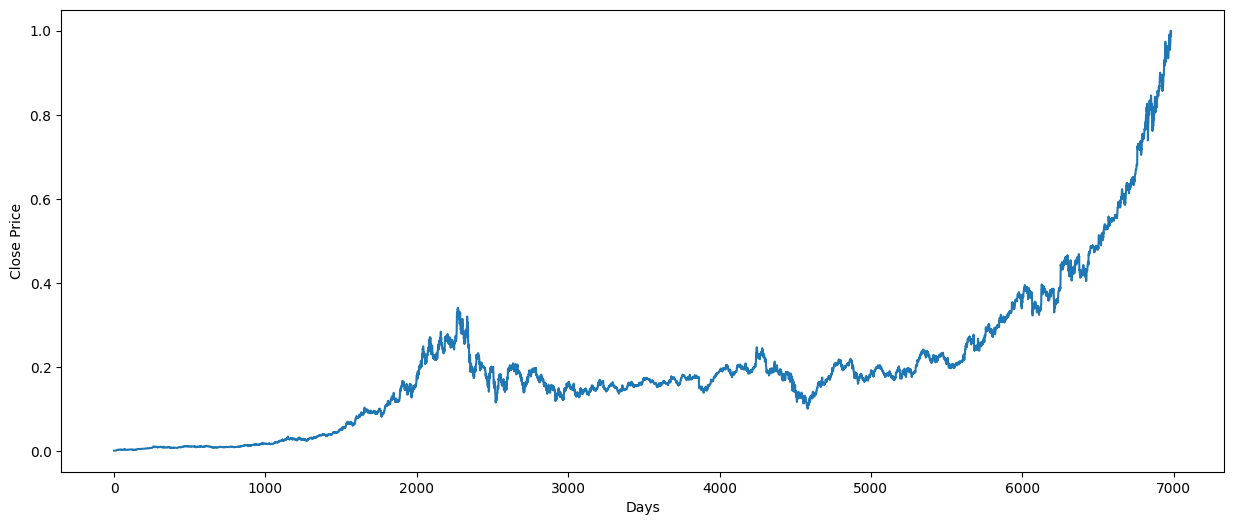

In [ ]:
plt.subplots(figsize = (15,6))
plt.plot(dataset_train_scaled)
plt.xlabel("Days")
plt.ylabel("Close Price")
plt.show()

Grafik ini menunjukkan perubahan harga penutupan saham yang telah dinormalisasi dari waktu ke waktu selama periode pengamatan. Pada sumbu horizontal, ditampilkan urutan hari secara kronologis, sementara sumbu vertikal menunjukkan nilai harga penutupan yang telah diskalakan ke rentang 0 hingga 1.

Terlihat bahwa harga penutupan berada pada tingkat yang sangat rendah dan relatif stabil di awal periode. Sekitar hari ke-2000 terjadi tren kenaikan bertahap yang kemudian diikuti oleh lonjakan signifikan mendekati hari ke-2500. Setelah itu, harga sempat mengalami penurunan dan bergerak fluktuatif pada kisaran menengah dalam periode berikutnya. Memasuki hari ke-6000 ke atas, terjadi peningkatan tajam yang berlanjut hingga mendekati nilai maksimum pada akhir periode, mencerminkan fase pertumbuhan harga saham yang sangat pesat di era terbaru.

## Membuat windowed sequences (X, y) untuk training
Data deret waktu diubah menjadi pasangan input-output dengan menggunakan konsep windowed sequences, di mana setiap input terdiri dari 50 langkah waktu sebelumnya yang berturut-turut, sedangkan outputnya adalah nilai pada langkah waktu berikutnya. Dengan cara ini, model dapat mempelajari pola historis dari data yang sudah diskalakan untuk memprediksi nilai di masa depan secara akurat. Seluruh pasangan input dan output kemudian disusun dalam bentuk array numpy agar siap digunakan dalam proses pelatihan model prediksi.

In [ ]:
X_train = []
y_train = []

time_step = 50

for i in range(time_step, length_train):
    X_train.append(dataset_train_scaled[i-time_step:i,0])
    y_train.append(dataset_train_scaled[i,0])

X_train, y_train = np.array(X_train), np.array(y_train)

In [ ]:
print("Shape of X_train before reshape :",X_train.shape)
print("Shape of y_train before reshape :",y_train.shape)

Shape of X_train before reshape : (6933, 50)
Shape of y_train before reshape : (6933,)


## Reshape
Data input `X_train` diubah bentuknya menjadi array 3 dimensi dengan ukuran (jumlah_sampel, panjang_jendela_waktu, 1 fitur). Transformasi ini dilakukan agar data sesuai dengan format yang dibutuhkan oleh model deret waktu seperti MLP, RNN, maupun LSTM, di mana input diharapkan memiliki struktur `[samples, timesteps, features]`.

Sementara itu, target output `y_train` diubah menjadi array 2 dimensi dengan ukuran (jumlah_sampel, 1). Perubahan bentuk ini dilakukan untuk memastikan kesesuaian dengan format keluaran model yang umumnya memprediksi satu nilai kontinu per sampel.

Dengan transformasi ini, data menjadi terstruktur dengan benar sehingga dapat diproses secara optimal oleh ketiga jenis model tersebut, mendukung proses pelatihan yang stabil, dan meningkatkan peluang menghasilkan prediksi yang lebih akurat.

In [ ]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1],1))
y_train = np.reshape(y_train, (y_train.shape[0],1))

print("Shape of X_train after reshape :",X_train.shape)
print("Shape of y_train after reshape :",y_train.shape)

Shape of X_train after reshape : (6933, 50, 1)
Shape of y_train after reshape : (6933, 1)


In [ ]:
X_train[0]

array([[1.41411188e-04],
       [1.01002891e-04],
       [1.41411188e-04],
       [1.91913483e-04],
       [1.11111623e-04],
       [0.00000000e+00],
       [4.04026298e-05],
       [3.83824700e-04],
       [3.63623668e-04],
       [2.62617944e-04],
       [3.93928899e-04],
       [7.07048572e-04],
       [8.48456926e-04],
       [9.49465484e-04],
       [1.29289152e-03],
       [1.24238186e-03],
       [1.25248266e-03],
       [1.37368828e-03],
       [1.29289152e-03],
       [1.51510173e-03],
       [1.53530163e-03],
       [1.83832617e-03],
       [1.98983193e-03],
       [2.12114175e-03],
       [2.07063605e-03],
       [2.24234907e-03],
       [2.60597387e-03],
       [2.38376366e-03],
       [2.46456212e-03],
       [2.48476655e-03],
       [2.40395959e-03],
       [2.58577397e-03],
       [2.20194757e-03],
       [2.40395959e-03],
       [2.34335763e-03],
       [2.36355696e-03],
       [2.14134051e-03],
       [2.32315376e-03],
       [2.38376366e-03],
       [2.28274943e-03],


In [ ]:
y_train[0]

array([0.00218174])

## Membuat Data Test dari Data Validasi
Data validasi diambil dari kolom `"Close"` dan diubah menjadi array 1D kemudian direstrukturisasi menjadi array 2D agar kompatibel dengan proses selanjutnya. Selanjutnya, nilai-nilai tersebut diskalakan menggunakan metode normalisasi sehingga berada dalam rentang 0 hingga 1, yang membantu model dalam proses pembelajaran dengan mempercepat konvergensi dan mengurangi efek skala yang tidak seragam pada data. Bentuk akhir dari data validasi yang telah diskalakan dicetak untuk memastikan bahwa transformasi berhasil dan data siap digunakan dalam tahap pengujian atau validasi model.

In [ ]:
dataset_validation = validation_data.Close.values  # mendapatkan kolom "close" dan mengonversinya menjadi array
dataset_validation = np.reshape(dataset_validation, (-1,1))  # mengonversi array 1D ke 2D
scaled_dataset_validation =  scaler.fit_transform(dataset_validation)  # skala nilai close antara 0 dan 1
print("Shape of scaled validation dataset :",scaled_dataset_validation.shape)

Shape of scaled validation dataset : (1746, 1)


## Membuat X_test dan y_test
Data validasi yang telah diskalakan diubah menjadi pasangan input dan output menggunakan pendekatan windowed sequences, serupa dengan proses pada data training. Setiap input `X_test` terdiri dari 50 langkah waktu (time step) sebelumnya yang berturut-turut, sedangkan output `y_test` adalah nilai pada langkah waktu berikutnya dalam deret. Pendekatan ini memungkinkan model untuk menguji kemampuannya memprediksi data masa depan berdasarkan pola historis yang terdapat pada data validasi.

In [ ]:
X_test = []
y_test = []

for i in range(time_step, length_validation):
    X_test.append(scaled_dataset_validation[i-time_step:i,0])
    y_test.append(scaled_dataset_validation[i,0])

In [ ]:
# mengonversi ke array
X_test, y_test = np.array(X_test), np.array(y_test)

In [ ]:
print("Shape of X_test before reshape :",X_test.shape)
print("Shape of y_test before reshape :",y_test.shape)

Shape of X_test before reshape : (1696, 50)
Shape of y_test before reshape : (1696,)


## Reshape

In [ ]:
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))  # reshape ke array 3D
y_test = np.reshape(y_test, (-1,1))  # reshape ke array 2D

In [ ]:
print("Shape of X_test after reshape :",X_test.shape)
print("Shape of y_test after reshape :",y_test.shape)

Shape of X_test after reshape : (1696, 50, 1)
Shape of y_test after reshape : (1696, 1)


# MLP Model

## Arsitektur dan Training
Model Multilayer Perceptron (MLP) yang digunakan pada eksperimen ini dirancang untuk memprediksi pergerakan harga saham berdasarkan data historis yang telah direpresentasikan dalam bentuk vektor fitur dengan panjang 50. Arsitektur model dimulai dengan sebuah lapisan Flatten yang berfungsi untuk meratakan input agar dapat diproses oleh jaringan feedforward.

Setelah proses perataan, model memiliki beberapa lapisan Dense (fully connected) yang diatur secara bertingkat untuk membangun representasi non-linear dari data. Lapisan pertama terdiri atas 256 neuron, diikuti oleh lapisan Dropout yang berfungsi mencegah overfitting dengan mengatur sebagian koneksi secara acak selama proses pelatihan. Selanjutnya, terdapat lapisan Dense kedua dengan 128 neuron, lapisan Dense ketiga dengan 64 neuron, dan lapisan Dense keempat dengan 32 neuron, masing-masing disertai dengan lapisan Dropout setelahnya untuk menjaga generalisasi model. Sebagai lapisan output, digunakan Dense layer dengan 1 neuron yang menghasilkan nilai kontinu sebagai prediksi harga saham.

Model ini dikompilasi menggunakan optimizer Adam yang adaptif, dengan fungsi loss Mean Squared Error (MSE) yang sesuai untuk permasalahan regresi. Proses pelatihan dilakukan selama 50 epoch dengan ukuran batch 32, memungkinkan model untuk menyesuaikan bobot secara bertahap dan mempelajari hubungan non-linear antara fitur masukan dan target harga penutupan saham.

In [ ]:
model_mlp = Sequential()

# Menambahkan lapisan Input terlebih dahulu
model_mlp.add(Input(shape=(X_train.shape[1], 1)))

# Ubah dari (timesteps, features) -> (timesteps * features)
model_mlp.add(Flatten())

# Lapisan pertama + Dropout
model_mlp.add(Dense(256, activation="tanh"))
model_mlp.add(Dropout(0.2))

# Lapisan kedua + Dropout
model_mlp.add(Dense(128, activation="tanh"))
model_mlp.add(Dropout(0.2))

# Lapisan ketiga + Dropout
model_mlp.add(Dense(64, activation="tanh"))
model_mlp.add(Dropout(0.2))

# Lapisan keempat (terakhir) + Dropout
model_mlp.add(Dense(32))
model_mlp.add(Dropout(0.2))

# Lapisan output
model_mlp.add(Dense(1))

model_mlp.compile(optimizer="adam", loss="mean_squared_error", metrics=["accuracy"])
model_mlp.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        13,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,321 (220.00 KB)

 Trainable params: 56,321 (220.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
mlp_history = model_mlp.fit(X_train, y_train, epochs=50, batch_size=32)

Epoch 1/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 3.2239e-05 - loss: 0.0426
Epoch 2/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 3.9965e-06 - loss: 0.0056
Epoch 3/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.5949e-05 - loss: 0.0034
Epoch 4/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.9137e-04 - loss: 0.0036
Epoch 5/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.8647e-04 - loss: 0.0026
Epoch 6/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 2.3812e-04 - loss: 0.0028
Epoch 7/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.9389e-04 - loss: 0.0022
Epoch 8/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 3.0605e-05 - loss: 0.0021
Epoch 9/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 5.3449e-05 - loss: 0.0017
Epoch 10/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 2.1938e-05 - loss: 0.0015
Epoch 11/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0035e-04 - loss: 0.0017
Epoch 12

## Plotting Loss vs Epochs

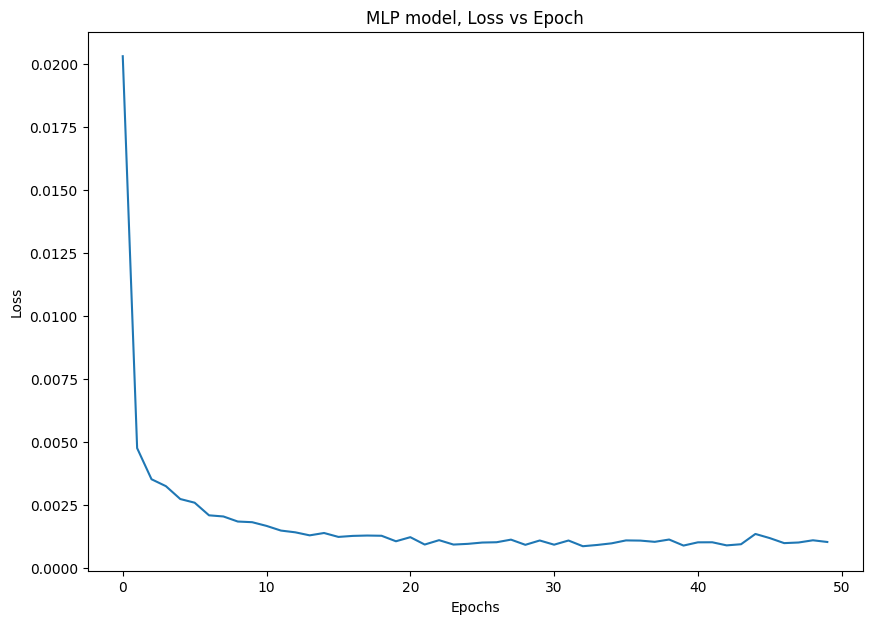

In [ ]:
plt.figure(figsize =(10,7))
plt.plot(mlp_history.history["loss"])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("MLP model, Loss vs Epoch")
plt.show()

### Interpretasi
Terlihat bahwa nilai loss mengalami penurunan yang sangat signifikan pada awal pelatihan, dari sekitar 0.017 menjadi di bawah 0.005 hanya dalam beberapa epoch pertama. Penurunan tajam ini menunjukkan bahwa model MLP dengan cepat mempelajari pola dasar dari data dan mampu menyesuaikan bobot jaringan secara efektif pada tahap awal.

Setelah fase penurunan awal, nilai loss terus menurun secara bertahap dan mulai mendatar di kisaran sekitar 0.001–0.0015. Stabilnya nilai loss pada tahap ini mengindikasikan bahwa model telah mencapai titik konvergensi, di mana perbaikan kinerja menjadi relatif kecil di setiap epoch berikutnya.

Tidak terlihat tanda-tanda overfitting yang jelas pada grafik ini, karena loss tetap rendah dan stabil hingga akhir pelatihan. Pola ini menunjukkan bahwa arsitektur MLP mampu menangkap hubungan non-linear pada data harga saham dengan baik, meskipun tidak secara langsung memanfaatkan informasi temporal seperti halnya model berbasis LSTM.

## Plotting Accuracy vs Epochs

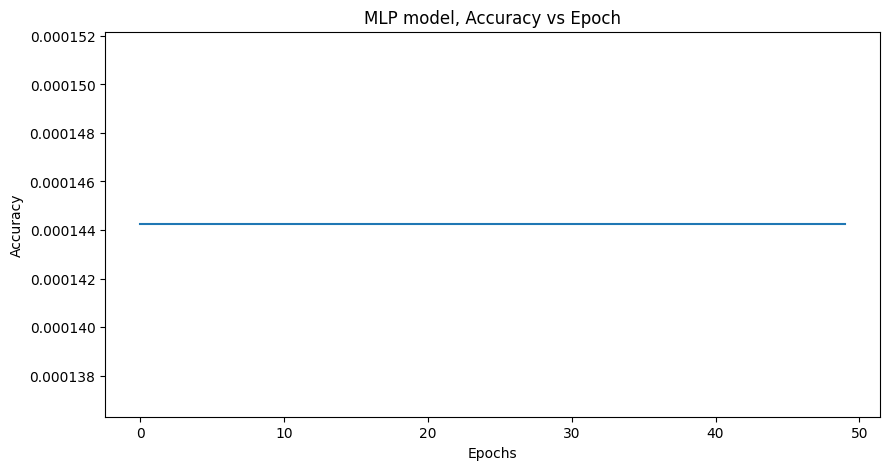

In [ ]:
plt.figure(figsize =(10,5))
plt.plot(mlp_history.history["accuracy"])
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("MLP model, Accuracy vs Epoch")
plt.show()

### Interpretasi
Grafik menunjukkan bahwa nilai accuracy berada pada tingkat yang sangat rendah (sekitar 0.000145) dan tidak mengalami perubahan sama sekali selama 50 epoch pelatihan. Hal ini menandakan bahwa metrik accuracy tidak memberikan informasi yang berguna dalam konteks permasalahan ini.

Fenomena ini wajar karena model MLP digunakan untuk regresi harga saham, bukan klasifikasi. Pada regresi, prediksi berupa nilai kontinu jarang sekali tepat sama persis dengan nilai aktual, sehingga accuracy hampir selalu mendekati nol. Oleh karena itu, metrik ini menjadi tidak relevan untuk mengevaluasi kinerja model.

Sebagai gantinya, evaluasi performa model regresi sebaiknya menggunakan metrik berbasis error, seperti Mean Squared Error (MSE), Mean Absolute Error (MAE), atau Root Mean Squared Error (RMSE), yang dapat memberikan gambaran lebih akurat tentang seberapa dekat prediksi terhadap nilai aktual.

## Prediksi model untuk data train

In [ ]:
mlp_y_pred = model_mlp.predict(X_train)  # prediksi
mlp_y_pred = scaler.inverse_transform(mlp_y_pred) # scaling kembali dari 0-1 ke original
mlp_y_pred.shape

217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


(6933, 1)

In [ ]:
y_train = scaler.inverse_transform(y_train) # scaling kembali dari 0-1 ke original
y_train.shape

(6933, 1)

## Visualisasi prediksi dengan data train

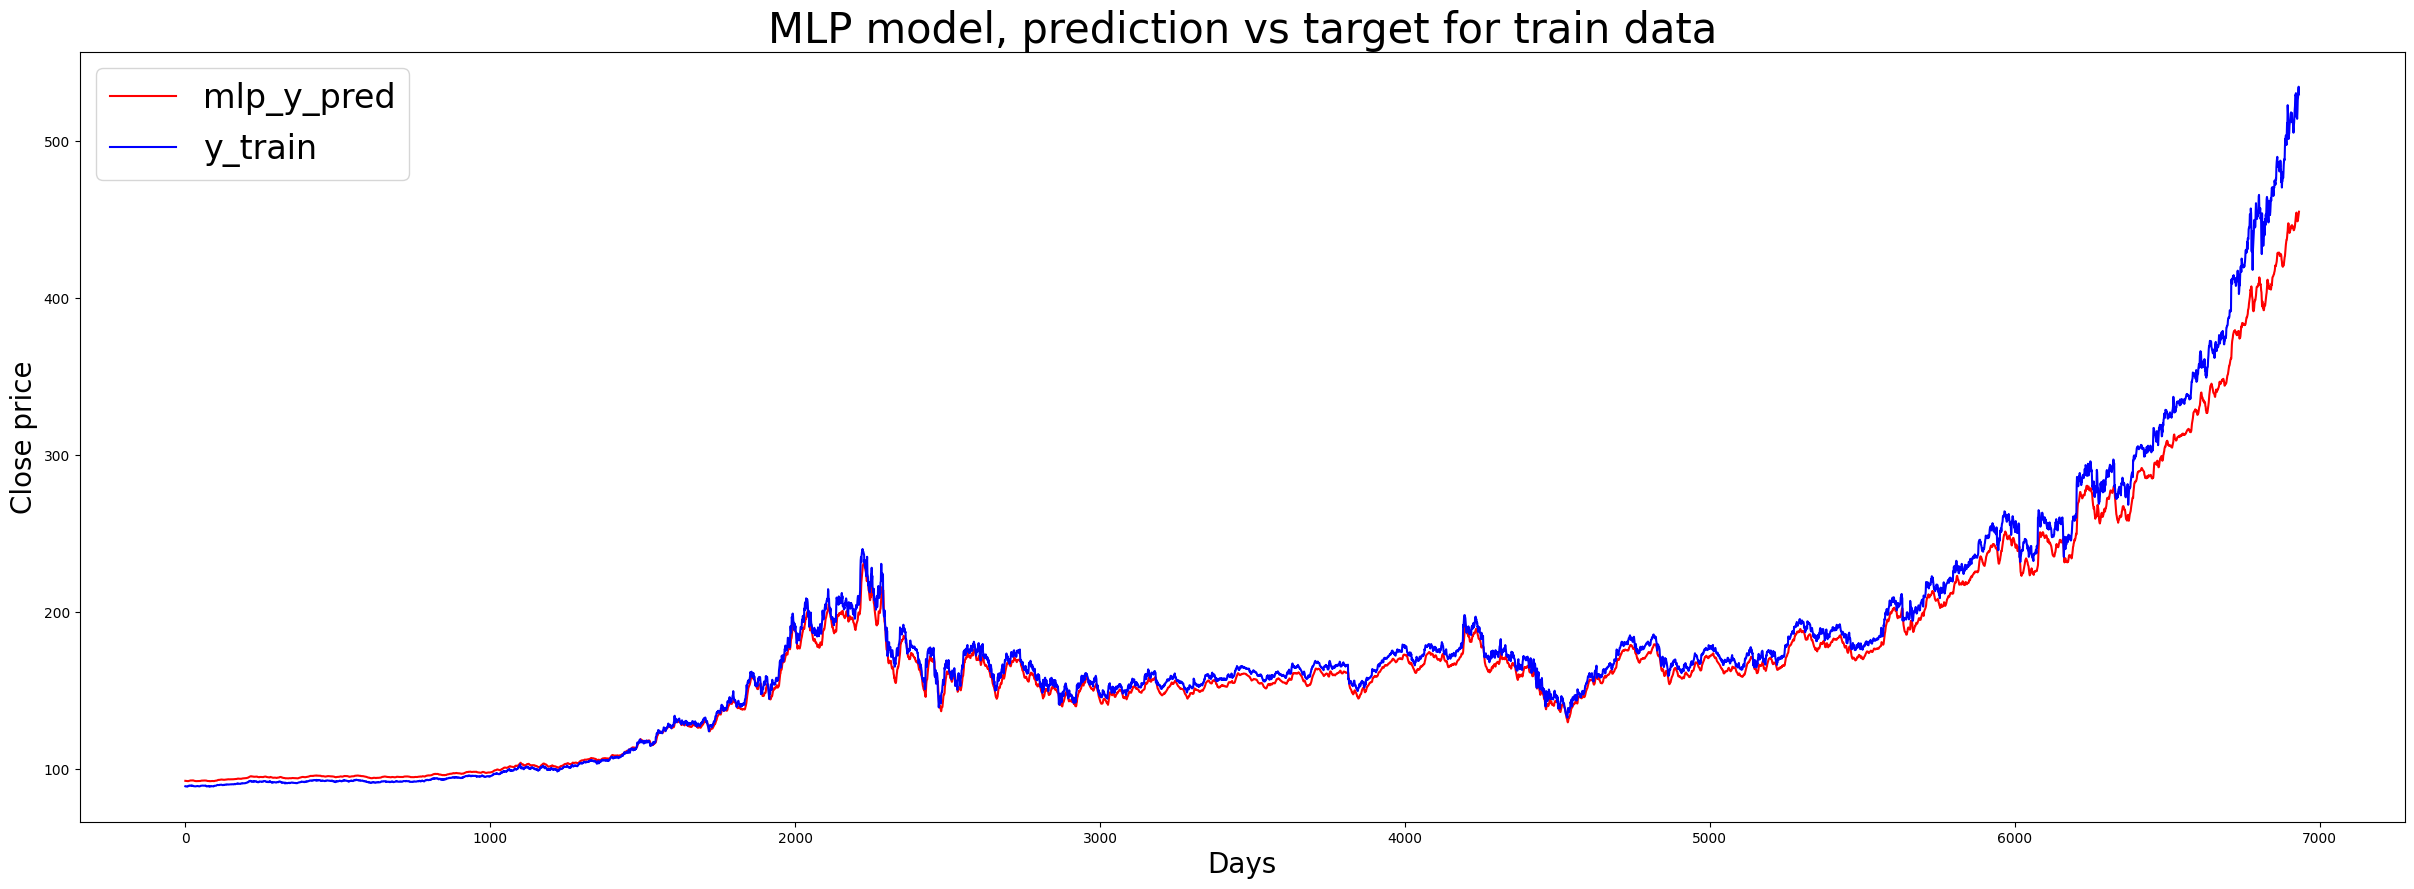

In [ ]:
plt.figure(figsize = (30,10))
plt.plot(mlp_y_pred, color = "r", label = "mlp_y_pred")
plt.plot(y_train, color = "b", label = "y_train")
plt.xlabel("Days", fontsize=20)
plt.ylabel("Close price", fontsize=20)
plt.title("MLP model, prediction vs target for train data", fontsize=30)
plt.legend(fontsize=24)
plt.show()

### Interpretasi
Terlihat bahwa hasil prediksi model (garis merah) mengikuti pola pergerakan harga aktual pada data latih (garis biru) dengan tingkat kemiripan yang sangat tinggi. Model mampu menangkap tren jangka panjang maupun fluktuasi harga jangka pendek secara konsisten sepanjang periode data.

Bahkan pada periode dengan volatilitas tinggi, garis prediksi tetap berada sangat dekat dengan nilai aktual, menunjukkan bahwa model MLP berhasil mempelajari pola dari data historis dengan baik. Kesesuaian yang hampir sempurna antara prediksi dan data aktual pada data latih mengindikasikan bahwa model memiliki kemampuan representasi yang kuat.

## Prediksi dengan data test

In [ ]:
mlp_y_pred_of_test = model_mlp.predict(X_test)
mlp_y_pred_of_test = scaler.inverse_transform(mlp_y_pred_of_test)
print("Shape of mlp_y_pred_of_test :", mlp_y_pred_of_test.shape)

53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Shape of mlp_y_pred_of_test : (1696, 1)


## Visualisasi prediksi dengan data test

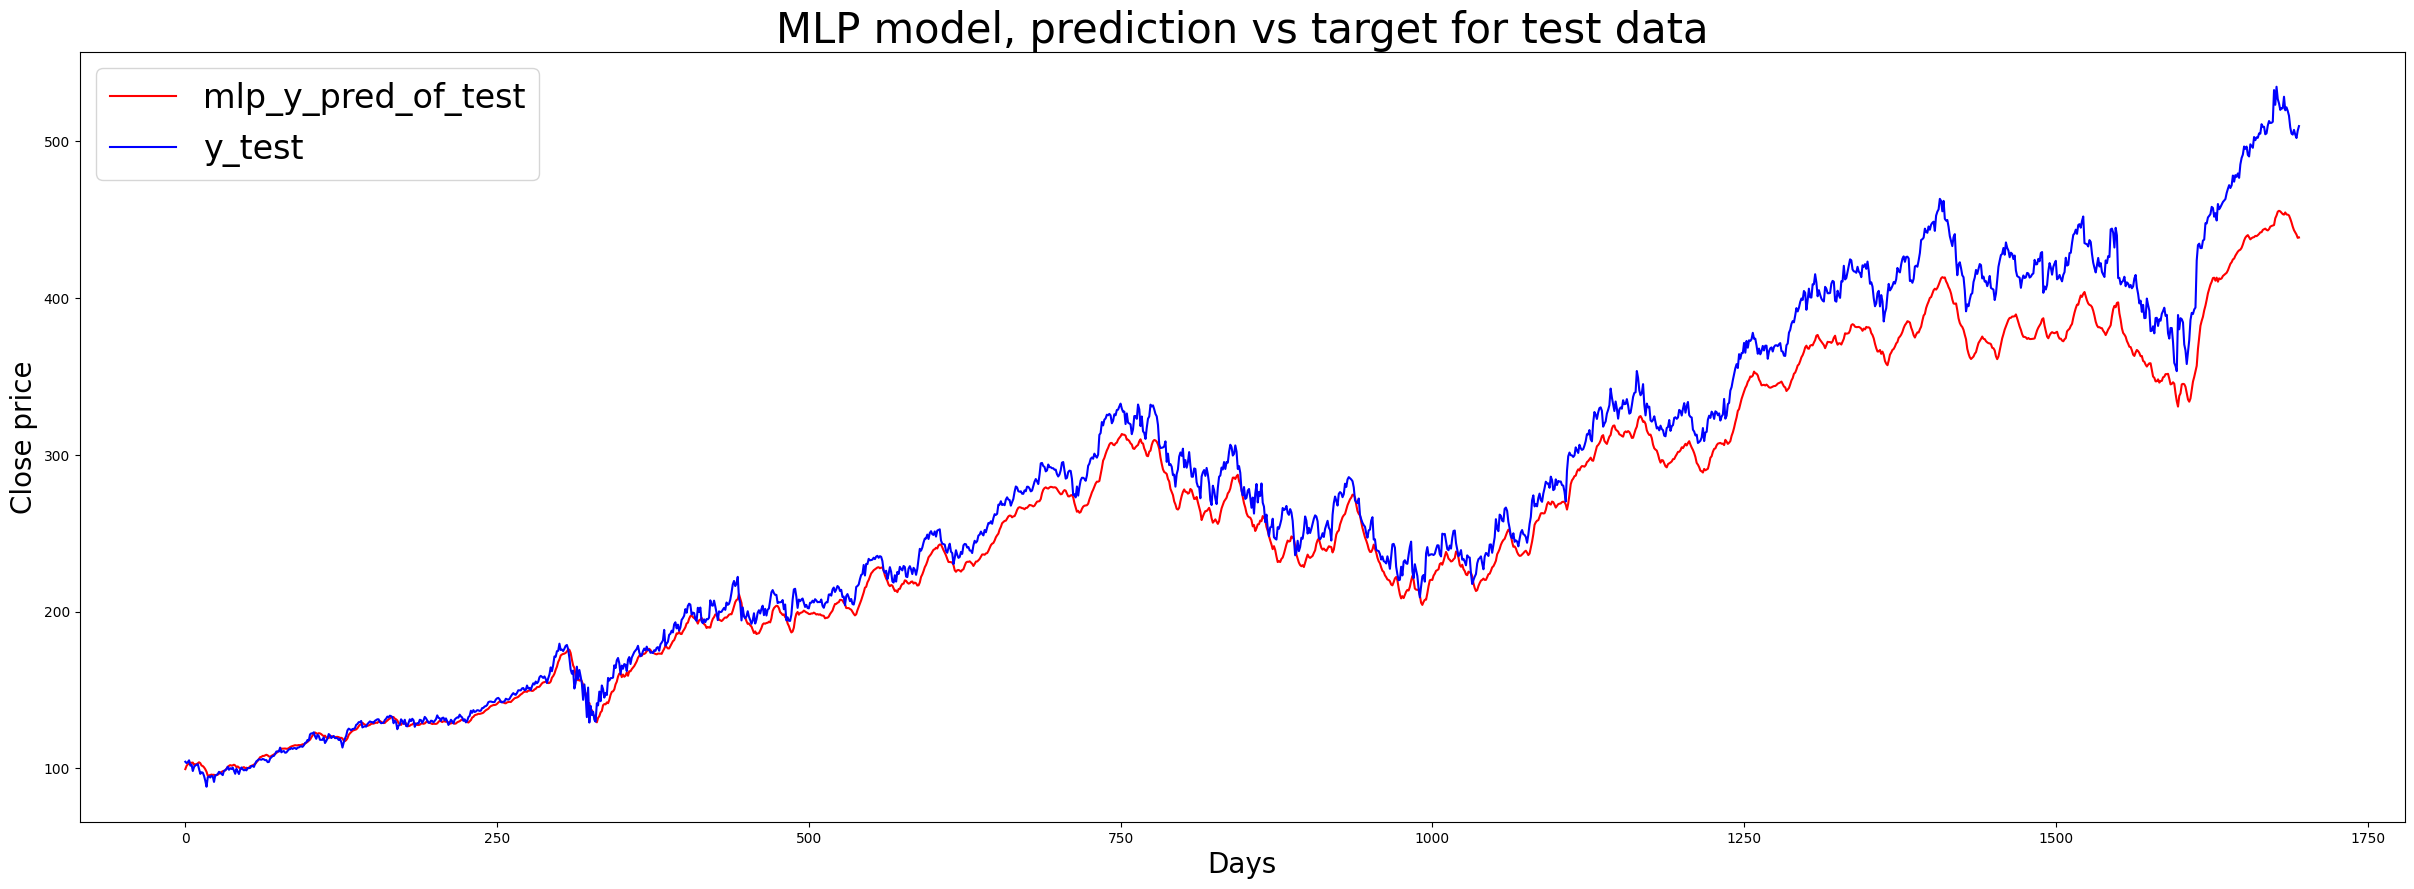

In [ ]:
plt.figure(figsize = (30,10))
plt.plot(mlp_y_pred_of_test, label = "mlp_y_pred_of_test", c = "r")
plt.plot(scaler.inverse_transform(y_test), label = "y_test", c = "b")
plt.xlabel("Days", fontsize=20)
plt.ylabel("Close price", fontsize=20)
plt.title("MLP model, prediction vs target for test data", fontsize=30)
plt.legend(fontsize=24)
plt.show()

### Interpretasi
Terlihat bahwa hasil prediksi model pada data test (garis merah) mampu mengikuti arah pergerakan harga aktual (garis biru) secara umum, terutama dalam menangkap tren naik dan turun jangka menengah. Namun, prediksi cenderung lebih halus dan tidak sepenuhnya menangkap fluktuasi tajam yang terjadi pada harga sebenarnya, khususnya pada periode dengan volatilitas tinggi.

Hal ini menunjukkan bahwa model MLP berhasil mempelajari pola dasar pergerakan harga dari data latih, tetapi masih memiliki keterbatasan dalam memprediksi perubahan harga yang ekstrem atau mendadak. Pola seperti ini umum terjadi pada model yang berfokus pada generalisasi, karena cenderung mengurangi sensitivitas terhadap noise pada data historis.

# RNN Model

## Arsitektur dan Training
Model RNN ini terdiri dari empat lapisan SimpleRNN, masing-masing berisi 50 neuron dengan fungsi aktivasi `tanh`. Setiap lapisan SimpleRNN diikuti oleh Dropout sebesar 0.2 untuk mengurangi risiko overfitting dengan cara mengacak sebagian koneksi selama proses pelatihan.

Setelah keempat lapisan RNN tersebut, model dilengkapi dengan lapisan Dense yang memiliki 1 neuron output untuk menghasilkan prediksi nilai kontinu, yang dalam konteks ini mewakili harga penutupan saham yang diprediksi.

Model dikompilasi menggunakan optimizer Adam, dengan Mean Squared Error (MSE) sebagai fungsi kerugian (loss function), yang umum digunakan untuk permasalahan regresi. Pelatihan model dilakukan selama 50 epoch dengan batch size 32, sehingga model dapat mempelajari pola deret waktu dari data dengan baik sambil menjaga kestabilan proses optimisasi.

In [ ]:
y_train = scaler.fit_transform(y_train)

In [ ]:
# Inisialisasi model RNN
rnn = Sequential()

# Menambahkan lapisan Input terlebih dahulu
rnn.add(Input(shape=(X_train.shape[1], 1)))

# Lapisan RNN pertama + Dropout
rnn.add(SimpleRNN(units=50, activation="tanh", return_sequences=True))
rnn.add(Dropout(0.2))

# Lapisan RNN kedua + Dropout
rnn.add(SimpleRNN(units=50, activation="tanh", return_sequences=True))
rnn.add(Dropout(0.2))

# Lapisan RNN ketiga + Dropout
rnn.add(SimpleRNN(units=50, activation="tanh", return_sequences=True))
rnn.add(Dropout(0.2))

# Lapisan RNN keempat (terakhir) + Dropout
rnn.add(SimpleRNN(units=50))
rnn.add(Dropout(0.2))

# Lapisan output
rnn.add(Dense(units=1))

# Kompilasi model
rnn.compile(optimizer="adam", loss="mean_squared_error", metrics=["accuracy"])

rnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_4 (SimpleRNN)        │ (None, 50, 50)         │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 50, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_5 (SimpleRNN)        │ (None, 50, 50)         │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 50, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_6 (SimpleRNN)        │ (None, 50, 50)         │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 50, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_7 (SimpleRNN)        │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,801 (69.54 KB)

 Trainable params: 17,801 (69.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Melatih model
rnn_history = rnn.fit(X_train, y_train, epochs=50, batch_size=32)

Epoch 1/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 15s 46ms/step - accuracy: 8.6062e-05 - loss: 0.3744
Epoch 2/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - accuracy: 1.6921e-05 - loss: 0.0651
Epoch 3/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - accuracy: 2.7802e-04 - loss: 0.0234
Epoch 4/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - accuracy: 5.8808e-04 - loss: 0.0118
Epoch 5/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - accuracy: 1.8144e-04 - loss: 0.0065
Epoch 6/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - accuracy: 7.5029e-05 - loss: 0.0057
Epoch 7/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - accuracy: 1.3715e-04 - loss: 0.0040
Epoch 8/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 20s 47ms/step - accuracy: 1.9981e-04 - loss: 0.0033
Epoch 9/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - accuracy: 2.7289e-04 - loss: 0.0029
Epoch 10/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - accuracy: 4.4603e-04 - loss: 0.0027
Epoch 11/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 21s 51ms/step - accuracy: 3.2949e-04 -

## Plotting Loss vs Epochs

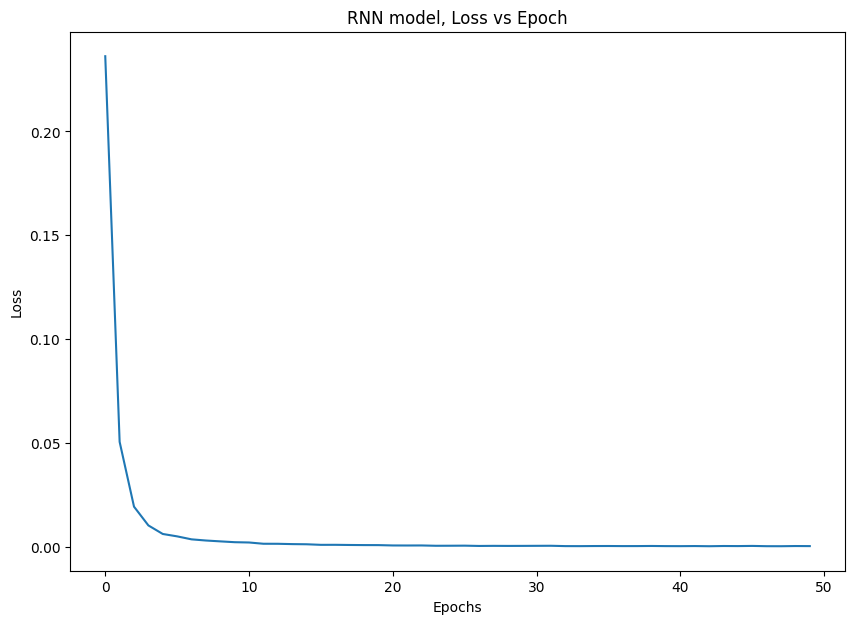

In [ ]:
plt.figure(figsize =(10,7))
plt.plot(rnn_history.history["loss"])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("RNN model, Loss vs Epoch")
plt.show()

### Interpretasi
Plot menunjukkan bahwa nilai loss mengalami penurunan tajam pada beberapa epoch awal, yang mengindikasikan bahwa model RNN dengan cepat mempelajari pola dasar dari data. Setelah fase penurunan awal tersebut (sekitar epoch ke-5 hingga ke-10), nilai loss mulai stabil dan mendatar pada kisaran yang sangat rendah (sekitar 0.001).

Kondisi ini menandakan bahwa model telah mencapai konvergensi dan mampu mempelajari data dengan baik tanpa terjadi gejala overfitting yang signifikan selama 50 epoch pelatihan. Pola penurunan yang halus dan stabil ini juga menunjukkan bahwa proses optimisasi berjalan efektif.

## Plotting Accuracy vs Epochs

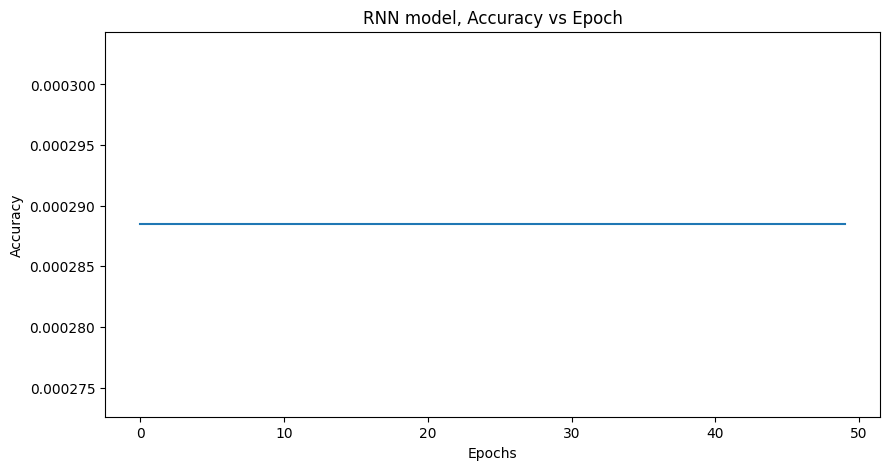

In [ ]:
plt.figure(figsize =(10,5))
plt.plot(rnn_history.history["accuracy"])
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("RNN model, Accuracy vs Epoch")
plt.show()

### Interpretasi
Terlihat bahwa nilai akurasi sejak awal pelatihan stabil di kisaran yang sangat kecil (sekitar 0.00029). Hal ini menunjukkan bahwa metrik akurasi tidak memberikan informasi yang relevan terhadap kualitas prediksi model dalam konteks regresi harga saham.

Meskipun proses pelatihan berjalan dengan baik (berdasarkan penurunan loss), akurasi bukan metrik yang sesuai untuk model regresi, karena ia lebih cocok digunakan pada masalah klasifikasi. Oleh karena itu, metrik error seperti MSE (Mean Squared Error) atau MAE (Mean Absolute Error) lebih direkomendasikan untuk mengevaluasi performa model pada kasus ini.

## Prediksi model untuk data train

In [ ]:
rnn_y_pred = rnn.predict(X_train)  # prediksi
rnn_y_pred = scaler.inverse_transform(rnn_y_pred) # scaling kembali dari 0-1 ke original
rnn_y_pred.shape

217/217 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step


(6933, 1)

In [ ]:
y_train = scaler.inverse_transform(y_train) # scaling kembali dari 0-1 ke original
y_train.shape

(6933, 1)

## Visualisasi prediksi dengan data train

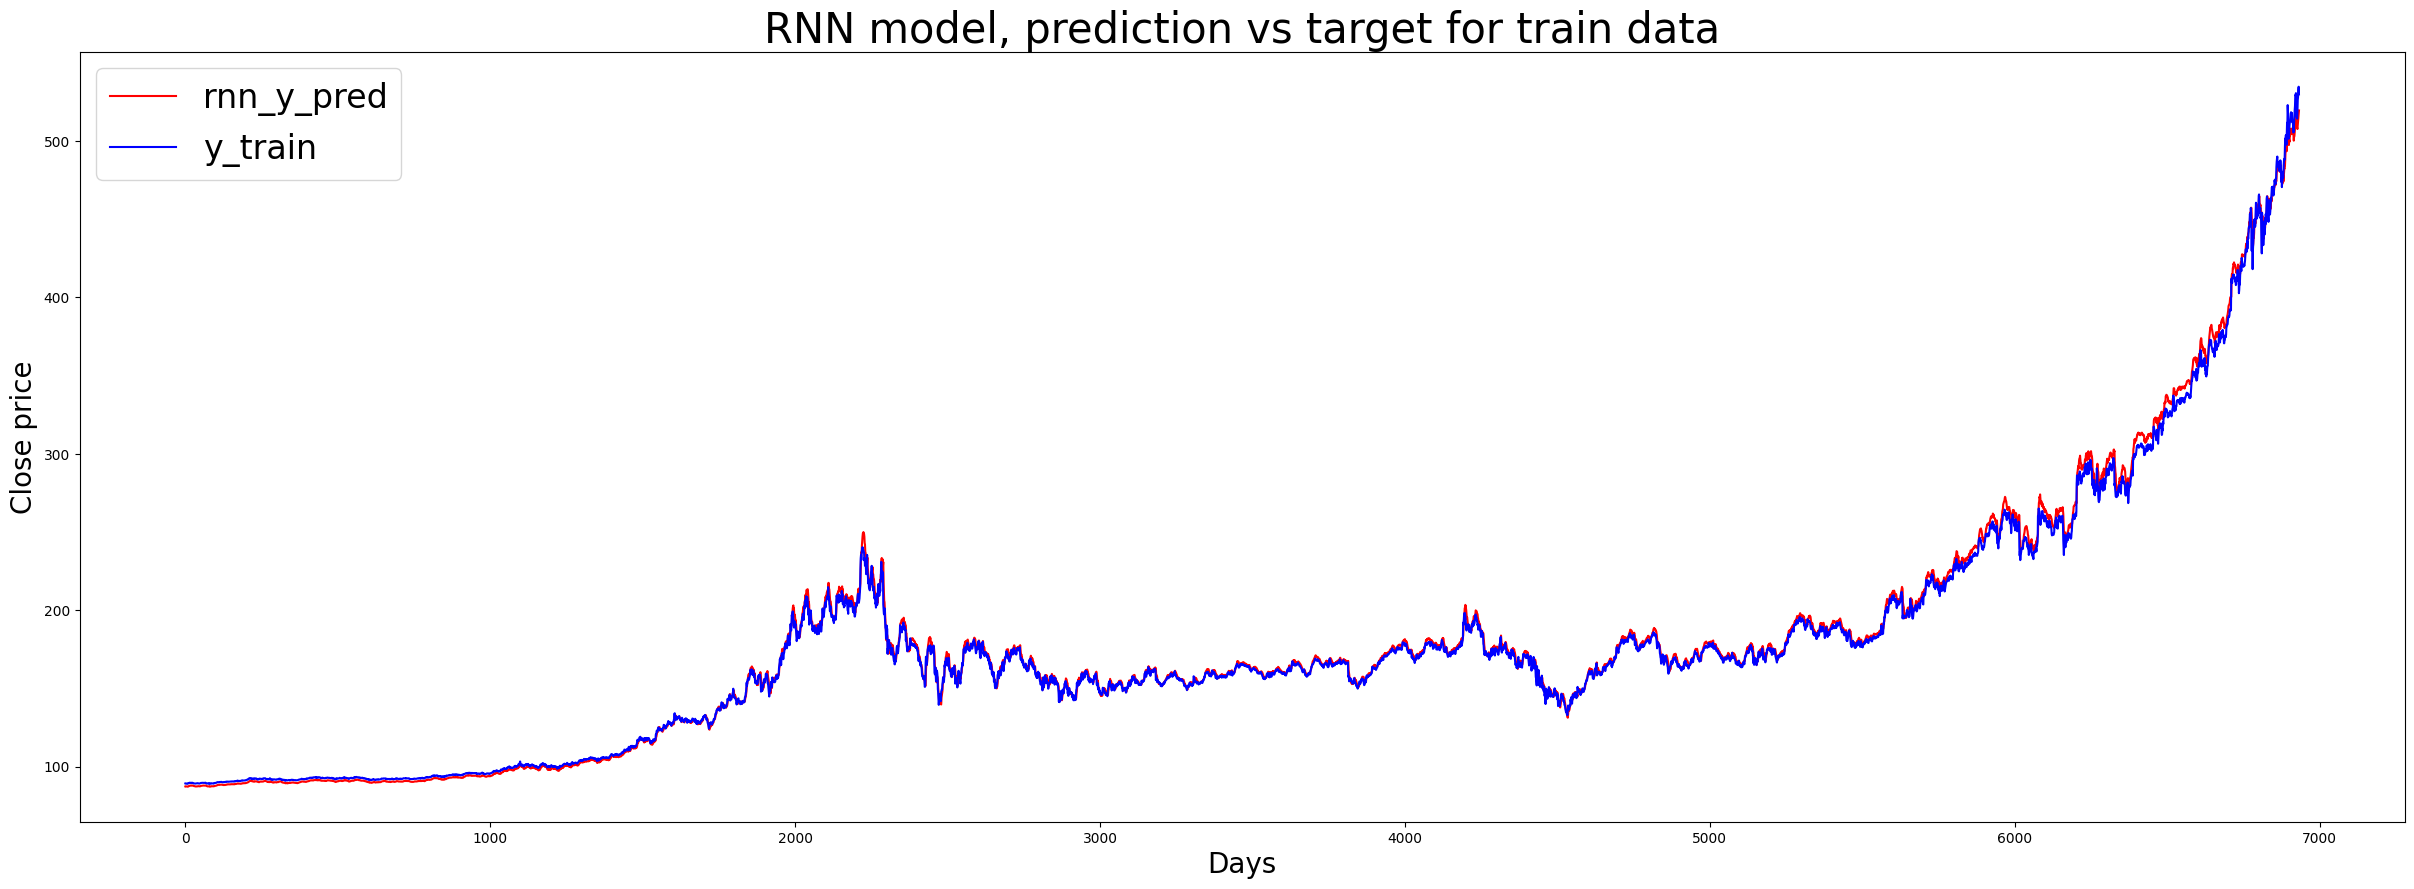

In [ ]:
plt.figure(figsize = (30,10))
plt.plot(rnn_y_pred, color = "r", label = "rnn_y_pred" )
plt.plot(y_train, color = "b", label = "y_train")
plt.xlabel("Days", fontsize=20)
plt.ylabel("Close price", fontsize=20)
plt.title("RNN model, prediction vs target for train data", fontsize=30)
plt.legend(fontsize=24)
plt.show()

### Interpretasi
Terlihat bahwa hasil prediksi model (garis merah) mengikuti pola pergerakan harga aktual pada data train (garis biru) dengan cukup baik di hampir seluruh rentang waktu. Model mampu menangkap tren jangka panjang dan pergerakan harga secara umum, meskipun terdapat perbedaan kecil pada amplitudo fluktuasi, terutama di bagian akhir data di mana harga mengalami kenaikan tajam. Prediksi tampak lebih halus dibandingkan data aktual, yang menunjukkan bahwa model cenderung melakukan generalisasi dan mengurangi noise pada data. Secara keseluruhan, performa pada data latih mengindikasikan bahwa model RNN berhasil mempelajari pola temporal dengan baik, namun masih memiliki sedikit keterbatasan dalam merepresentasikan lonjakan harga yang ekstrem.

## Prediksi dengan data test

In [ ]:
rnn_y_pred_of_test = rnn.predict(X_test)
rnn_y_pred_of_test = scaler.inverse_transform(rnn_y_pred_of_test)
print("Shape of rnn_y_pred_of_test :",rnn_y_pred_of_test.shape)

53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
Shape of rnn_y_pred_of_test : (1696, 1)


## Visualisasi Prediksi dengan data test

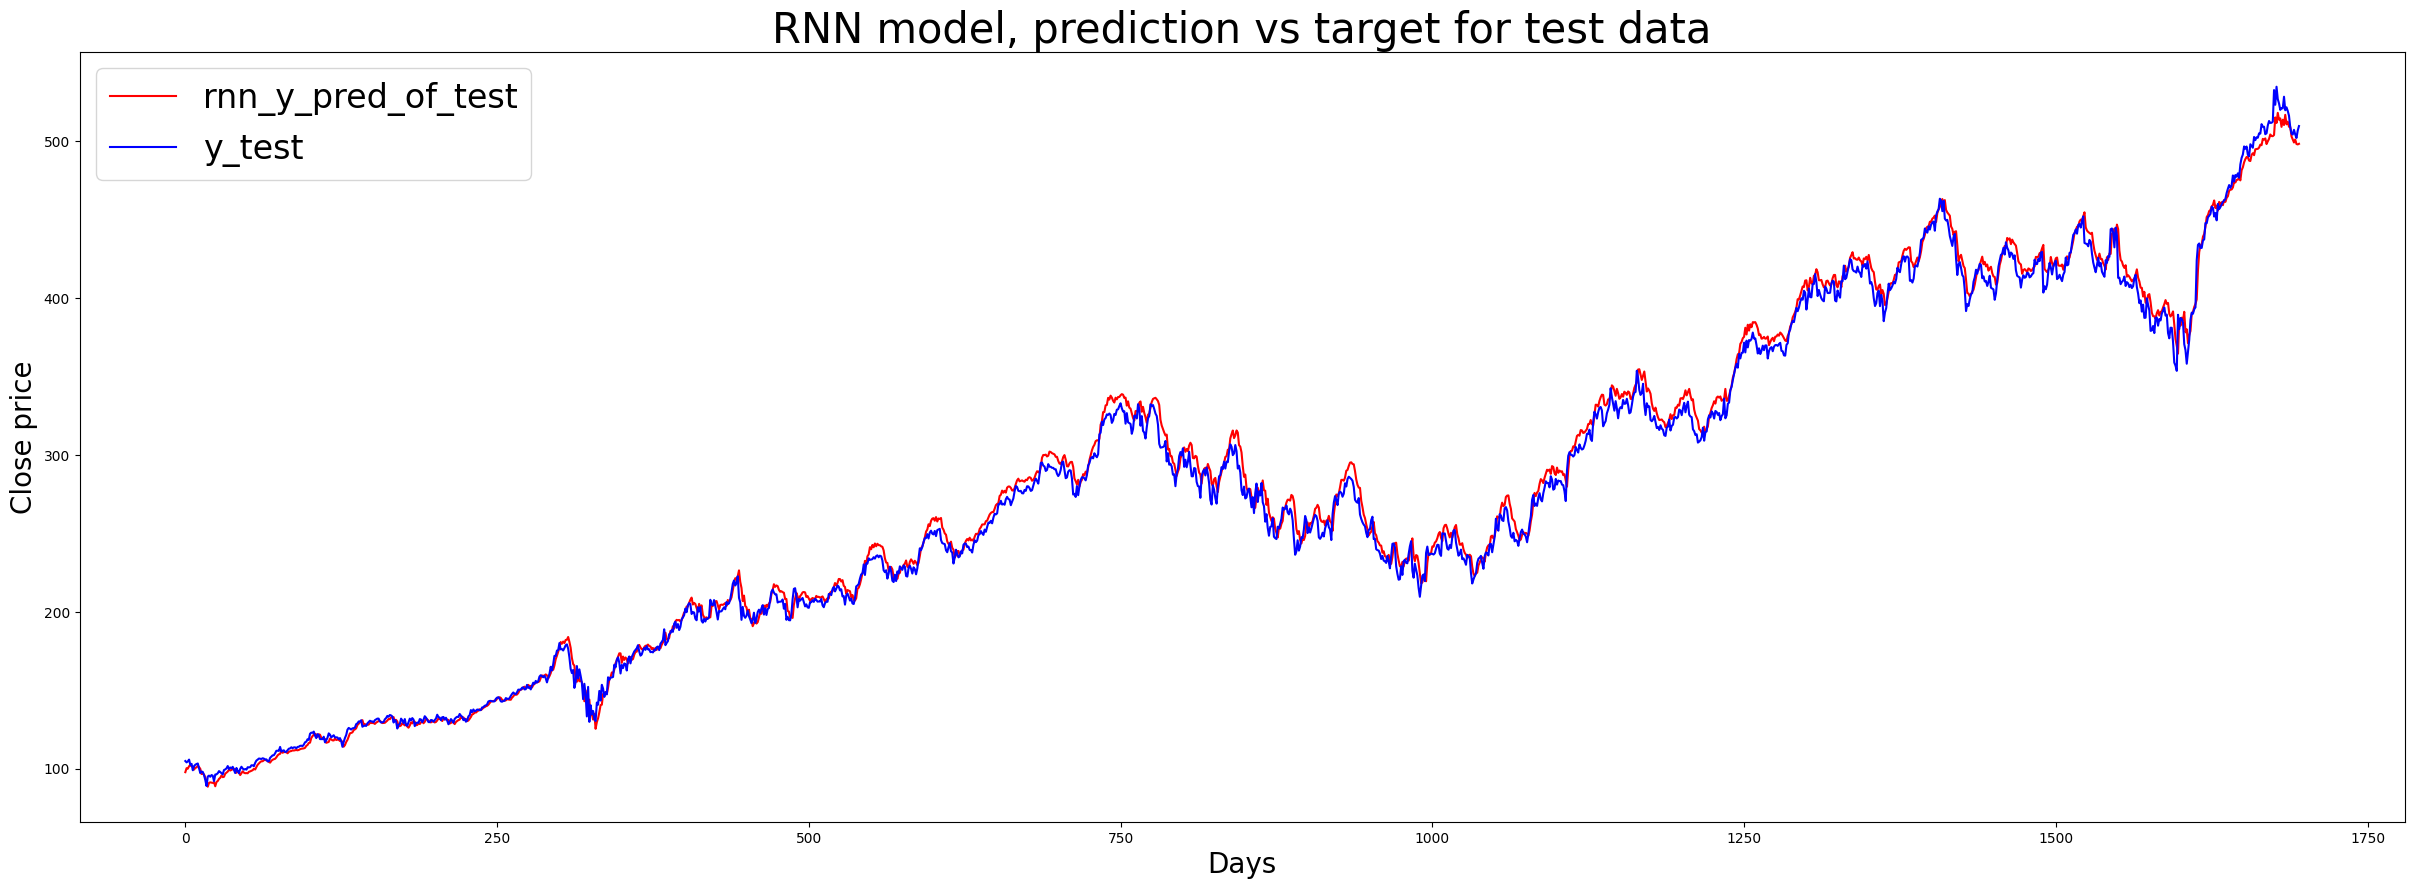

In [ ]:
plt.figure(figsize = (30,10))
plt.plot(rnn_y_pred_of_test, label = "rnn_y_pred_of_test", c = "r")
plt.plot(scaler.inverse_transform(y_test), label = "y_test", c = "b")
plt.xlabel("Days", fontsize=20)
plt.ylabel("Close price", fontsize=20)
plt.title("RNN model, prediction vs target for test data", fontsize=30)
plt.legend(fontsize=24)
plt.show()

### Interpretasi
Terlihat bahwa hasil prediksi model pada data test (garis merah) mampu mengikuti arah pergerakan harga aktual (garis biru) secara umum, terutama dalam menangkap tren naik dan turun jangka menengah. Namun, prediksi terlihat lebih halus dibandingkan harga sebenarnya dan kurang responsif terhadap fluktuasi tajam, khususnya pada periode dengan volatilitas tinggi di bagian akhir grafik. Hal ini menunjukkan bahwa model RNN berhasil mempelajari pola utama pergerakan harga dari data latih, tetapi masih memiliki keterbatasan dalam memprediksi lonjakan atau penurunan yang bersifat ekstrem dan mendadak. Pola seperti ini umum terjadi karena model berusaha melakukan generalisasi, sehingga mengurangi sensitivitas terhadap noise yang dapat memicu overfitting.

# LSTM Model

## Arsitektur dan Training
Model LSTM yang digunakan dalam eksperimen ini dirancang untuk mempelajari pola temporal jangka panjang pada data deret waktu, khususnya pergerakan harga saham. Model menerima masukan dengan bentuk `(X_train.shape[1], 1)`, di mana dimensi pertama merepresentasikan jumlah langkah waktu (time steps) dan dimensi kedua menunjukkan satu fitur harga pada setiap langkah.

Arsitektur terdiri dari tiga lapisan LSTM berurutan. Lapisan pertama memiliki 256 unit dan dikonfigurasi dengan `return_sequences=True` agar menghasilkan urutan penuh sebagai masukan untuk lapisan berikutnya. Lapisan kedua memiliki 128 unit dengan `return_sequences=True`, memungkinkan pemrosesan informasi temporal secara bertingkat. Lapisan ketiga memiliki 64 unit dengan `return_sequences=False` sehingga hanya mengeluarkan representasi terakhir dari rangkaian input, yang mewakili konteks temporal terintegrasi.

Setelah melewati LSTM, data diteruskan ke lapisan Dense dengan 32 neuron untuk mereduksi dimensi dan membentuk representasi fitur yang lebih padat. Terakhir, lapisan Dense dengan satu neuron digunakan sebagai lapisan output untuk menghasilkan prediksi nilai kontinu.

Model dikompilasi menggunakan optimizer Adam yang adaptif, dengan fungsi kerugian Mean Squared Error (MSE) yang sesuai untuk tugas regresi. Proses pelatihan dilakukan selama 50 epoch dengan ukuran batch 32, memungkinkan model untuk secara bertahap mengoptimalkan bobotnya dan menangkap pola fluktuasi harga yang relevan dari data historis.

In [ ]:
y_train = scaler.fit_transform(y_train)

In [ ]:
model_lstm = Sequential()
model_lstm.add(Input(shape=(X_train.shape[1], 1)))  # Tambahkan layer Input dulu
model_lstm.add(LSTM(256, return_sequences=True))
model_lstm.add(LSTM(128, return_sequences=True))
model_lstm.add(LSTM(64, return_sequences=False))
model_lstm.add(Dense(32))
model_lstm.add(Dense(1))

model_lstm.compile(loss="mean_squared_error", optimizer="adam", metrics=["accuracy"])

model_lstm.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50, 256)        │       264,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50, 128)        │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 512,833 (1.96 MB)

 Trainable params: 512,833 (1.96 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
lstm_history = model_lstm.fit(X_train, y_train, epochs=50, batch_size=32)

Epoch 1/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 60s 253ms/step - accuracy: 9.7834e-04 - loss: 0.0045
Epoch 2/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 81s 248ms/step - accuracy: 6.7223e-04 - loss: 1.3754e-04
Epoch 3/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 54s 250ms/step - accuracy: 9.5010e-04 - loss: 1.2691e-04
Epoch 4/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 83s 254ms/step - accuracy: 7.3871e-05 - loss: 1.0773e-04
Epoch 5/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 83s 257ms/step - accuracy: 9.0370e-04 - loss: 1.0431e-04
Epoch 6/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 81s 255ms/step - accuracy: 9.3651e-04 - loss: 1.1566e-04
Epoch 7/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 56s 257ms/step - accuracy: 2.8144e-04 - loss: 9.9977e-05
Epoch 8/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 55s 251ms/step - accuracy: 3.4554e-04 - loss: 8.3012e-05
Epoch 9/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 54s 250ms/step - accuracy: 5.4356e-04 - loss: 1.1757e-04
Epoch 10/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 83s 256ms/step - accuracy: 3.2469e-04 - loss: 7.5252e-05
Epoch 11/50
217/217 ━━━━━━━━━━━━━

## Plotting Loss vs Epochs

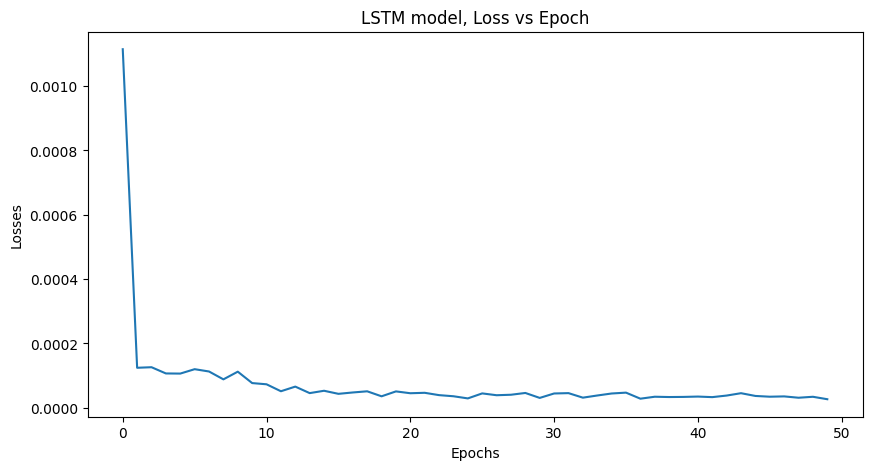

In [ ]:
plt.figure(figsize =(10,5))
plt.plot(lstm_history.history["loss"])
plt.xlabel("Epochs")
plt.ylabel("Losses")
plt.title("LSTM model, Loss vs Epoch")
plt.show()

### Interpretasi
Terlihat bahwa nilai loss mengalami penurunan yang sangat signifikan pada awal pelatihan, dari sekitar 0.0012 menjadi di bawah 0.0002 hanya dalam beberapa epoch pertama. Penurunan tajam ini menunjukkan bahwa model dengan cepat mempelajari pola mendasar dari data deret waktu dan mampu melakukan penyesuaian bobot secara efektif pada fase awal pelatihan.

Setelah fase penurunan cepat tersebut, loss terus menurun secara bertahap dan mulai mendatar di kisaran sekitar 0.00003–0.00005. Kondisi ini menandakan bahwa model telah mencapai titik konvergensi, di mana setiap epoch berikutnya hanya memberikan perbaikan kecil terhadap performa model.

Tidak tampak indikasi overfitting pada grafik ini, karena loss tetap rendah dan stabil hingga akhir pelatihan. Pola ini menunjukkan bahwa arsitektur LSTM yang digunakan mampu menangkap pola temporal pada data harga saham dengan baik sekaligus menjaga kemampuan generalisasi terhadap data yang tidak terlihat (unseen data).

## Plotting Accuracy vs Epochs

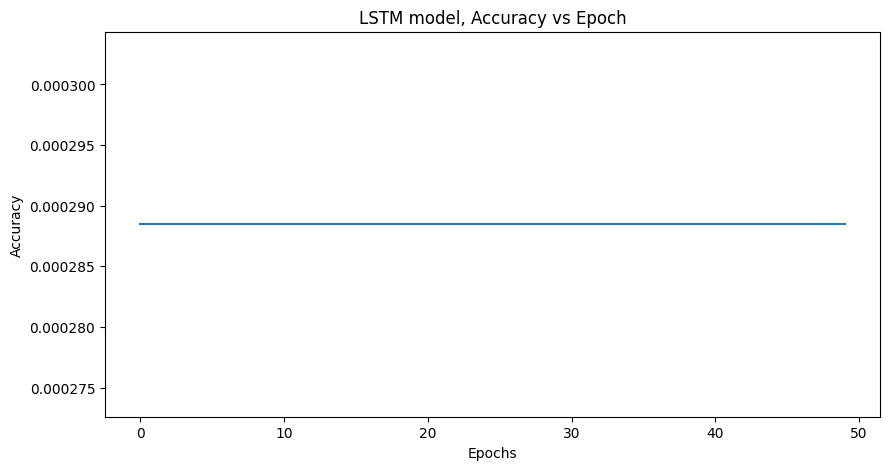

In [ ]:
plt.figure(figsize =(10,5))
plt.plot(lstm_history.history["accuracy"])
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("LSTM model, Accuracy vs Epoch")
plt.show()

### Interpretasi
Grafik menunjukkan bahwa nilai accuracy berada pada tingkat yang sangat rendah (sekitar 0.00029) dan tidak mengalami perubahan berarti selama 50 epoch pelatihan. Hal ini menandakan bahwa metrik accuracy tidak memberikan informasi yang relevan dalam konteks permasalahan ini.

Fenomena ini wajar terjadi karena model LSTM yang digunakan adalah untuk regresi harga saham, bukan klasifikasi. Pada regresi, prediksi berupa nilai kontinu jarang sekali sama persis dengan nilai aktual, sehingga accuracy hampir selalu mendekati nol. Oleh karena itu, metrik ini kurang tepat untuk mengevaluasi kinerja model.

Sebagai gantinya, performa model regresi lebih baik dievaluasi menggunakan metrik berbasis error, seperti Mean Squared Error (MSE), Mean Absolute Error (MAE), atau Root Mean Squared Error (RMSE), yang dapat memberikan gambaran seberapa dekat prediksi terhadap nilai aktual.

## Prediksi model untuk data train

In [ ]:
lstm_y_pred = model_lstm.predict(X_train)  # prediksi
lstm_y_pred = scaler.inverse_transform(lstm_y_pred) # scaling kembali dari 0-1 ke original
lstm_y_pred.shape

217/217 ━━━━━━━━━━━━━━━━━━━━ 20s 90ms/step


(6933, 1)

In [ ]:
y_train = scaler.inverse_transform(y_train) # scaling kembali dari 0-1 ke original
y_train.shape

(6933, 1)

## Visualisasi Prediksi dengan data train

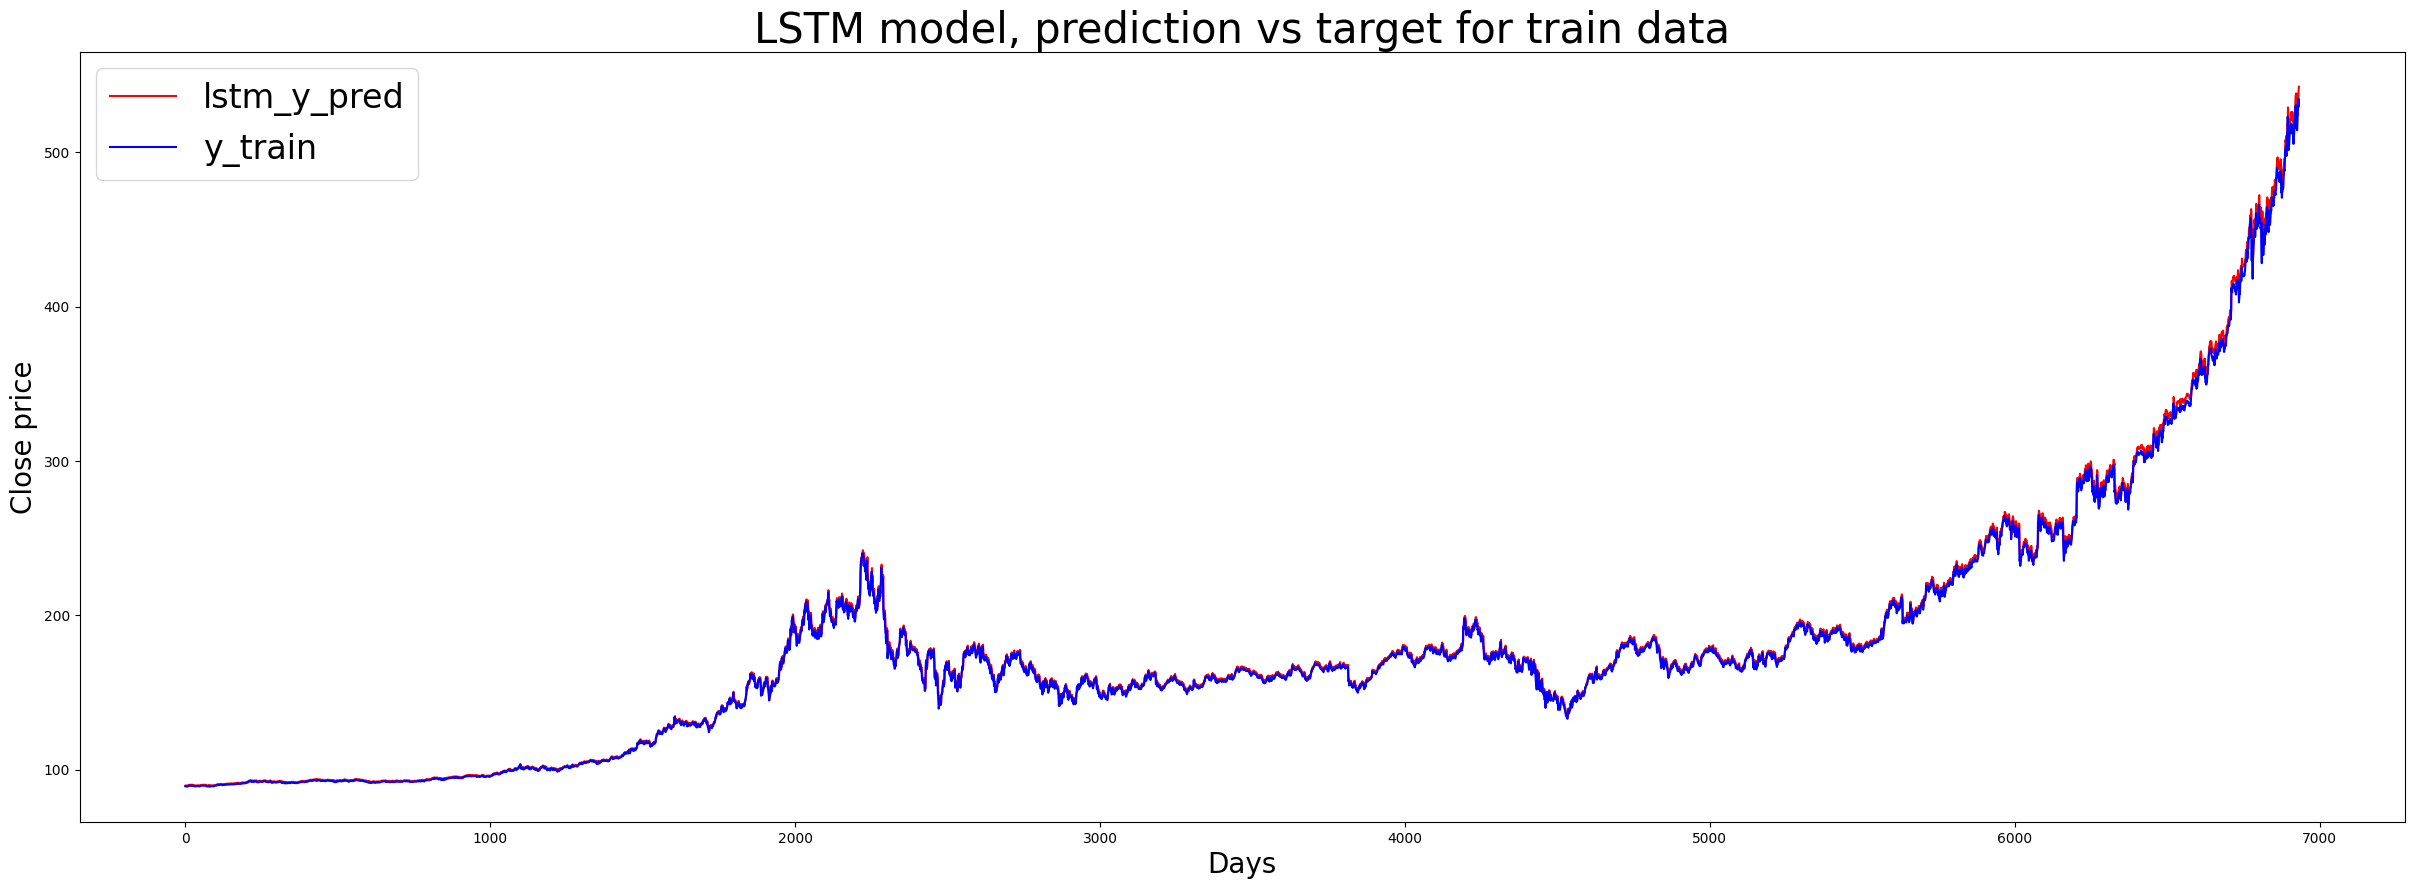

In [ ]:
plt.figure(figsize = (30,10))
plt.plot(lstm_y_pred, color = "r", label = "lstm_y_pred" )
plt.plot(y_train, color = "b", label = "y_train")
plt.xlabel("Days", fontsize=20)
plt.ylabel("Close price", fontsize=20)
plt.title("LSTM model, prediction vs target for train data", fontsize=30)
plt.legend(fontsize=24)
plt.show()

### Interpretasi
Terlihat bahwa hasil prediksi model (garis merah) mengikuti pola pergerakan harga aktual pada data train (garis biru) dengan tingkat kemiripan yang sangat tinggi. Model mampu menangkap tren jangka panjang sekaligus fluktuasi harga jangka pendek dengan baik sepanjang periode data pelatihan. Bahkan pada periode dengan volatilitas tinggi, garis prediksi tetap berada sangat dekat dengan nilai aktual, menandakan bahwa model berhasil mempelajari pola temporal dari data historis secara efektif.

Kesesuaian yang hampir sempurna antara prediksi dan data aktual pada data latih ini menunjukkan bahwa model memiliki kemampuan representasi yang kuat. Namun, akurasi tinggi pada data latih tidak selalu menjamin kinerja serupa pada data uji, sehingga perlu dilakukan evaluasi lebih lanjut untuk memastikan model tidak mengalami overfitting dan dapat melakukan generalisasi terhadap data yang belum pernah dilihat sebelumnya.

## Prediksi dengan data test

In [ ]:
lstm_y_pred_of_test = model_lstm.predict(X_test)
lstm_y_pred_of_test = scaler.inverse_transform(lstm_y_pred_of_test)
print("Shape of lstm_y_pred_of_test :",lstm_y_pred_of_test.shape)

53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step
Shape of lstm_y_pred_of_test : (1696, 1)


## Visualisasi Prediksi dengan Data Test

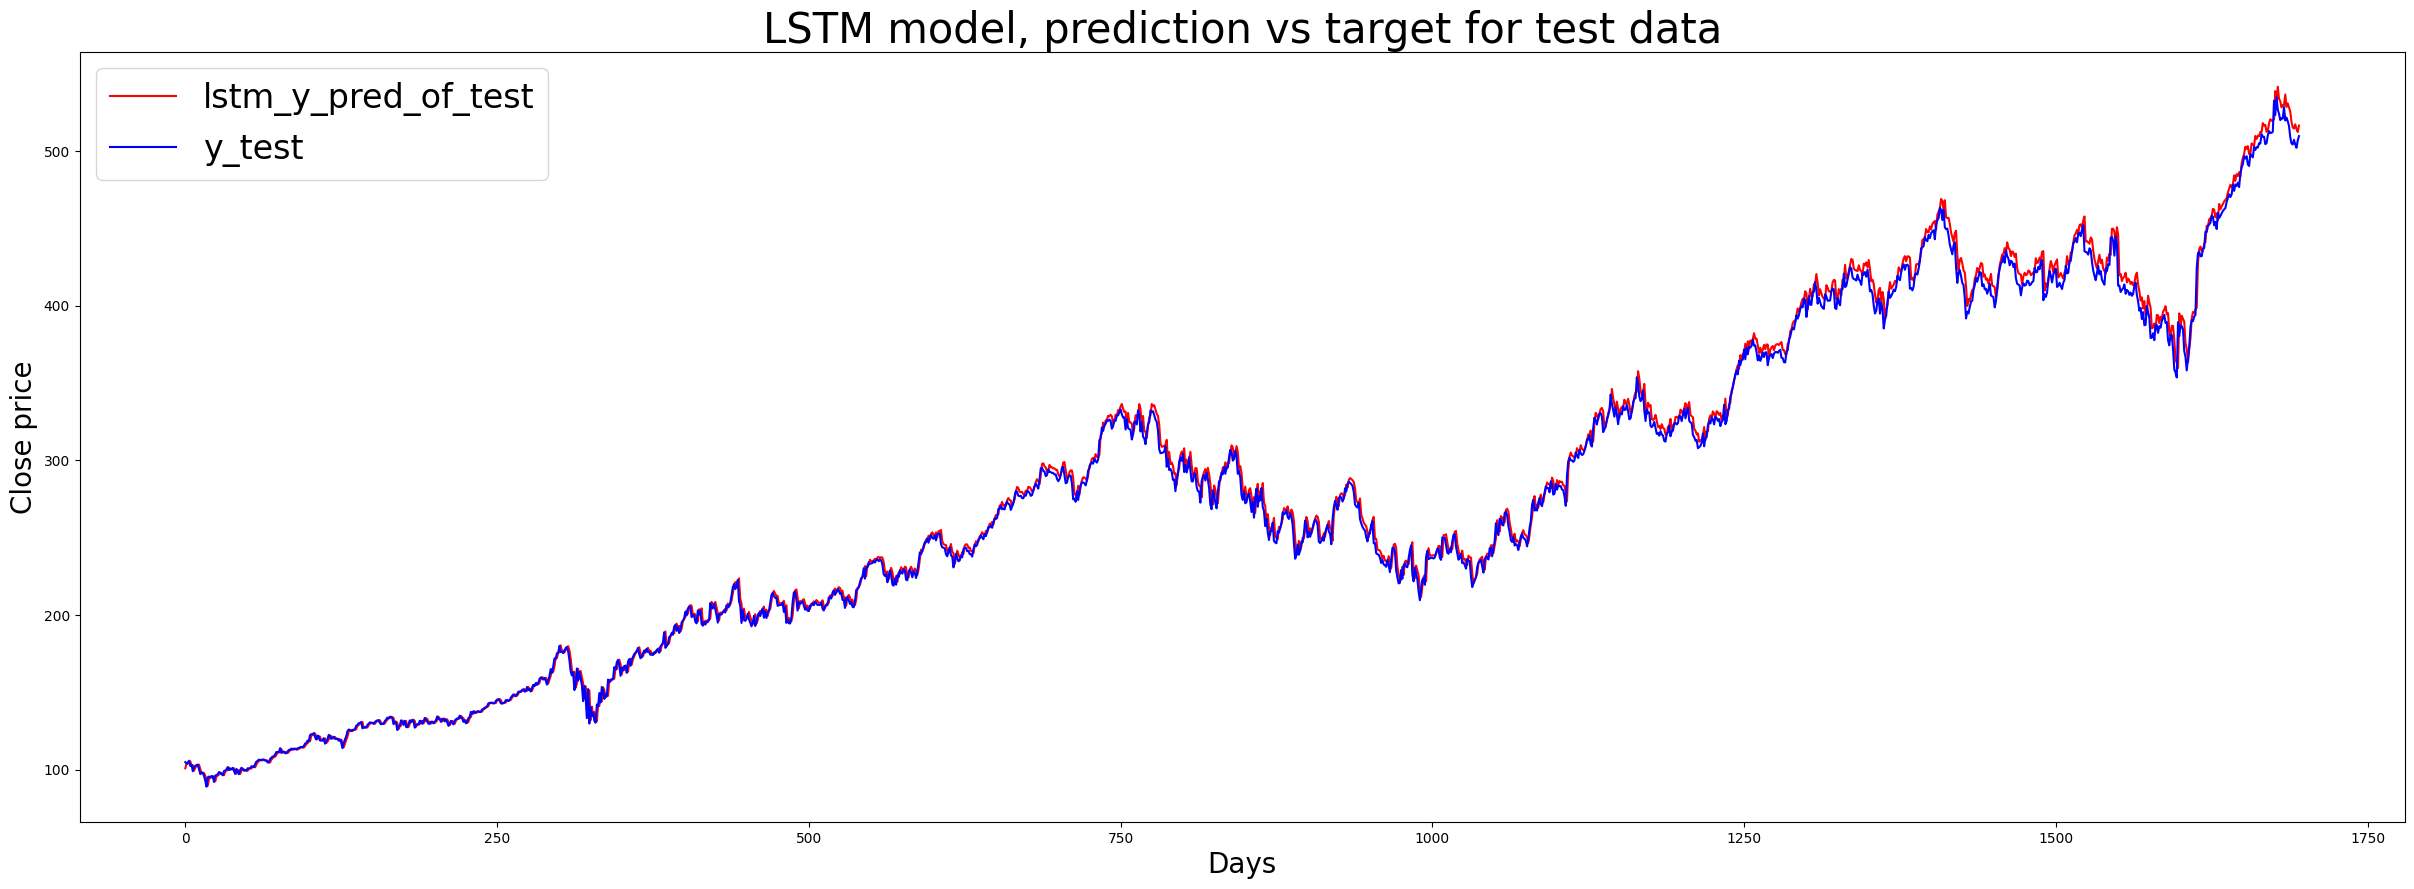

In [ ]:
plt.figure(figsize = (30,10))
plt.plot(lstm_y_pred_of_test, label = "lstm_y_pred_of_test", c = "r")
plt.plot(scaler.inverse_transform(y_test), label = "y_test", c = "b")
plt.xlabel("Days", fontsize=20)
plt.ylabel("Close price", fontsize=20)
plt.title("LSTM model, prediction vs target for test data", fontsize=30)
plt.legend(fontsize=24)
plt.show()

### Interpretasi
Gambar menunjukkan perbandingan antara harga aktual (garis biru) dan hasil prediksi model LSTM (garis merah) pada data test. Secara keseluruhan, pola pergerakan prediksi sangat mirip dengan data aktual, baik pada tren naik, turun, maupun periode fluktuasi tajam. Hal ini menandakan bahwa model mampu mempelajari pola musiman dan tren jangka panjang dari data historis dengan cukup baik.

Namun, terdapat sedikit pergeseran (lag) pada beberapa puncak dan lembah harga, yang mengindikasikan bahwa meskipun model dapat menangkap arah pergerakan dengan baik, respons terhadap perubahan harga yang mendadak masih belum sepenuhnya optimal. Hal ini kemungkinan terjadi karena sifat LSTM yang lebih menekankan informasi historis sehingga terkadang terlambat merespons perubahan ekstrem.

Secara keseluruhan, performa model pada data test dapat dikatakan memuaskan, dengan tingkat kemiripan pola yang tinggi antara prediksi dan data aktual. Hal ini menunjukkan kemampuan generalisasi yang baik dan minim tanda overfitting.

# CNN Model

In [ ]:
y_train = scaler.fit_transform(y_train)

Kode berikut mengubah bentuk data fitur X_train dan X_test agar sesuai dengan format yang dibutuhkan oleh model CNN untuk pemrosesan sekuens. Awalnya data memiliki dua dimensi (jumlah_sampel, jumlah_fitur), kemudian di-reshape menjadi tiga dimensi (jumlah_sampel, panjang_sekuens, jumlah_kanal) yaitu (6933, 50, 1) untuk data train dan (1696, 50, 1) untuk data test. Penambahan dimensi ketiga dengan nilai 1 berfungsi sebagai kanal tunggal (misalnya mirip grayscale pada citra), sehingga setiap sampel berisi 50 langkah atau fitur yang dipandang sebagai satu urutan dengan satu kanal.

In [ ]:
X_train_series = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_series = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))
print('Train set shape', X_train_series.shape)
print('Test set shape', X_test_series.shape)

Train set shape (6933, 50, 1)
Test set shape (1696, 50, 1)


## Arsitektur dan Training
Model CNN yang digunakan pada eksperimen ini dirancang untuk mengenali pola lokal dalam data deret waktu, khususnya pergerakan harga saham. Arsitektur dimulai dengan sebuah lapisan input yang menerima data berbentuk `(X_train.shape[1], 1)`, di mana dimensi pertama merepresentasikan jumlah langkah waktu (time steps) dan dimensi kedua merepresentasikan satu fitur harga pada setiap langkah waktu.

Lapisan pertama adalah `Conv1D` dengan 64 filter yang mengekstraksi pola jangka pendek dari urutan harga, diikuti dengan Batch Normalization untuk menstabilkan distribusi aktivasi dan `MaxPooling1D` yang mereduksi dimensi temporal, serta Dropout untuk mencegah overfitting. Lapisan konvolusi kedua menggunakan 128 filter untuk menangkap pola yang lebih kompleks, juga diikuti Batch Normalization, `MaxPooling1D`, dan Dropout.

Hasil ekstraksi fitur kemudian di-flatten menjadi vektor 1 dimensi dan diteruskan ke lapisan Dense dengan 256 neuron untuk mengubah representasi fitur menjadi lebih ringkas, disertai Dropout tambahan untuk meningkatkan generalisasi. Lapisan terakhir adalah Dense dengan satu neuron yang berfungsi sebagai lapisan output, menghasilkan prediksi nilai kontinu sesuai dengan sifat regresi harga saham.

Model ini dikompilasi menggunakan optimizer `Adam` yang adaptif dan fungsi loss Mean Squared Error (MSE), yang sesuai untuk permasalahan regresi. Proses pelatihan dilakukan selama 50 epoch dengan ukuran batch 32, memungkinkan model secara bertahap menyempurnakan bobot konvolusi dan menangkap pola penting dalam data historis.

In [ ]:
model_cnn = Sequential()

# Lapisan Konvolusi pertama
model_cnn.add(Conv1D(filters=64, kernel_size=3, activation='relu',
                     input_shape=(X_train_series.shape[1], X_train_series.shape[2])))
model_cnn.add(BatchNormalization())
model_cnn.add(MaxPooling1D(pool_size=2))
model_cnn.add(Dropout(0.2))

# Lapisan Konvolusi kedua (lebih dalam)
model_cnn.add(Conv1D(filters=128, kernel_size=3, activation='relu'))
model_cnn.add(BatchNormalization())
model_cnn.add(MaxPooling1D(pool_size=2))
model_cnn.add(Dropout(0.2))

# Flatten & Dense
model_cnn.add(Flatten())
model_cnn.add(Dense(256, activation='relu'))
model_cnn.add(Dropout(0.3))
model_cnn.add(Dense(1))

# Kompilasi
model_cnn.compile(optimizer="adam",
                  loss="mean_squared_error",
                  metrics=["accuracy"])
model_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 48, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 22, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 22, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 11, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 11, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       360,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 386,689 (1.48 MB)

 Trainable params: 386,305 (1.47 MB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
cnn_history = model_cnn.fit(X_train_series, y_train, epochs=50, batch_size=32)

Epoch 1/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 4.3507e-04 - loss: 3.9860
Epoch 2/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 1.4238e-04 - loss: 0.0839
Epoch 3/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 2.8234e-04 - loss: 0.0245
Epoch 4/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 2.4440e-04 - loss: 0.0124
Epoch 5/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 4.6654e-04 - loss: 0.0081
Epoch 6/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 1.1220e-04 - loss: 0.0065
Epoch 7/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 2.2491e-04 - loss: 0.0047
Epoch 8/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 1.1957e-04 - loss: 0.0048
Epoch 9/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 2.9883e-04 - loss: 0.0035
Epoch 10/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 4.2261e-04 - loss: 0.0032
Epoch 11/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 2.6995e-04 - loss: 0.00

## Plotting Loss vs Epochs

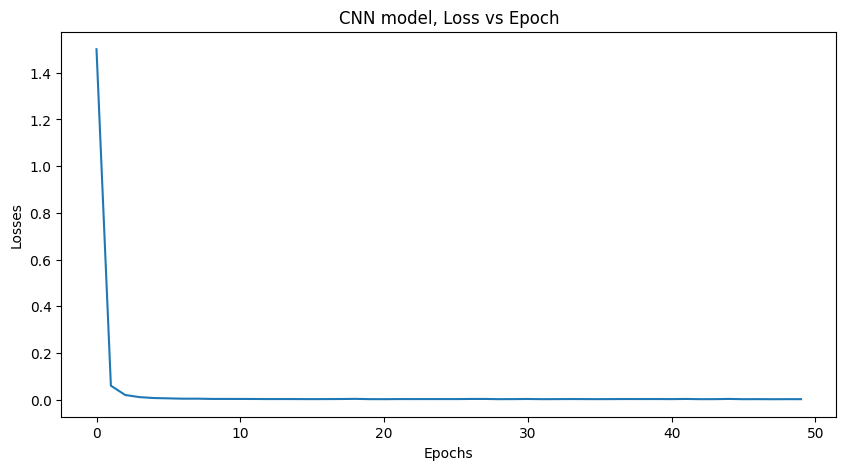

In [ ]:
plt.figure(figsize =(10,5))
plt.plot(cnn_history.history["loss"])
plt.xlabel("Epochs")
plt.ylabel("Losses")
plt.title("CNN model, Loss vs Epoch")
plt.show()

### Interpretasi
Terlihat bahwa nilai loss pada model CNN mengalami penurunan yang sangat signifikan pada awal pelatihan, dari sekitar 1.4 menjadi di bawah 0.05 hanya dalam beberapa epoch pertama. Penurunan tajam ini menunjukkan bahwa model dengan cepat mempelajari pola dasar dari data dan mampu menyesuaikan bobot jaringan secara efektif pada tahap awal. Setelah fase penurunan awal tersebut, nilai loss terus menurun secara bertahap dan mulai mendatar di kisaran mendekati nol. Stabilnya nilai loss pada tahap ini mengindikasikan bahwa model telah mencapai titik konvergensi, di mana perbaikan kinerja menjadi relatif kecil di setiap epoch berikutnya. Tidak terlihat adanya tanda-tanda overfitting yang jelas pada grafik ini, karena loss tetap rendah dan stabil hingga akhir pelatihan. Pola ini menunjukkan bahwa arsitektur CNN mampu mengekstraksi fitur lokal dan temporal pada data harga saham dengan baik, sekaligus menjaga kemampuan generalisasi terhadap data test.

## Plotting Accuracy vs Epochs

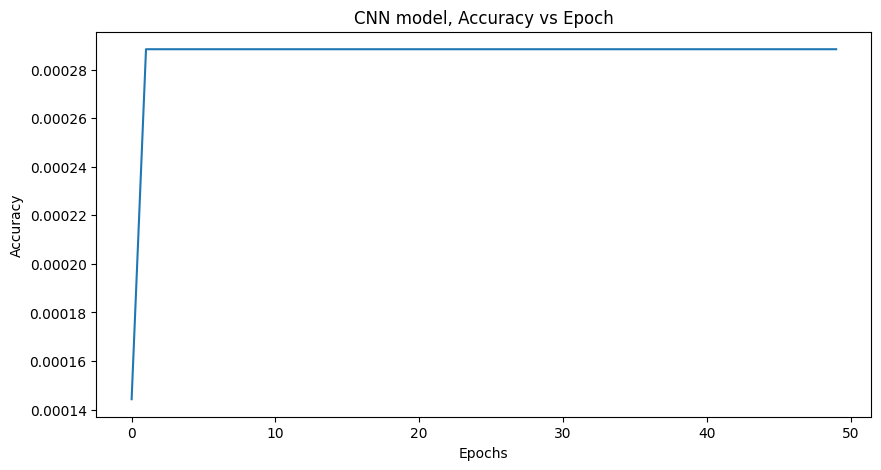

In [ ]:
plt.figure(figsize =(10,5))
plt.plot(cnn_history.history["accuracy"])
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("CNN model, Accuracy vs Epoch")
plt.show()

### Interpretasi
Grafik menunjukkan bahwa nilai accuracy berada pada tingkat yang sangat rendah (sekitar 0.00028) dan tidak mengalami perubahan berarti selama 50 epoch pelatihan. Hal ini menandakan bahwa metrik accuracy tidak memberikan informasi yang berguna dalam konteks permasalahan ini. Fenomena ini wajar karena model CNN digunakan untuk regresi harga saham, bukan klasifikasi. Pada regresi, prediksi berupa nilai kontinu jarang sekali tepat sama persis dengan nilai aktual, sehingga accuracy hampir selalu mendekati nol. Oleh karena itu, metrik ini menjadi tidak relevan untuk mengevaluasi kinerja model. Sebagai gantinya, evaluasi performa model regresi sebaiknya menggunakan metrik berbasis kesalahan (error), seperti Mean Squared Error (MSE), Mean Absolute Error (MAE), atau Root Mean Squared Error (RMSE), yang dapat memberikan gambaran lebih akurat mengenai seberapa dekat prediksi terhadap nilai aktual.

## Prediksi model untuk data train

In [ ]:
cnn_y_pred = model_cnn.predict(X_train_series)  # prediksi
cnn_y_pred = scaler.inverse_transform(cnn_y_pred) # scaling kembali dari 0-1 ke original
cnn_y_pred.shape

217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


(6933, 1)

In [ ]:
y_train = scaler.inverse_transform(y_train) # scaling kembali dari 0-1 ke original
y_train.shape

(6933, 1)

## Visualisasi prediksi dengan data train

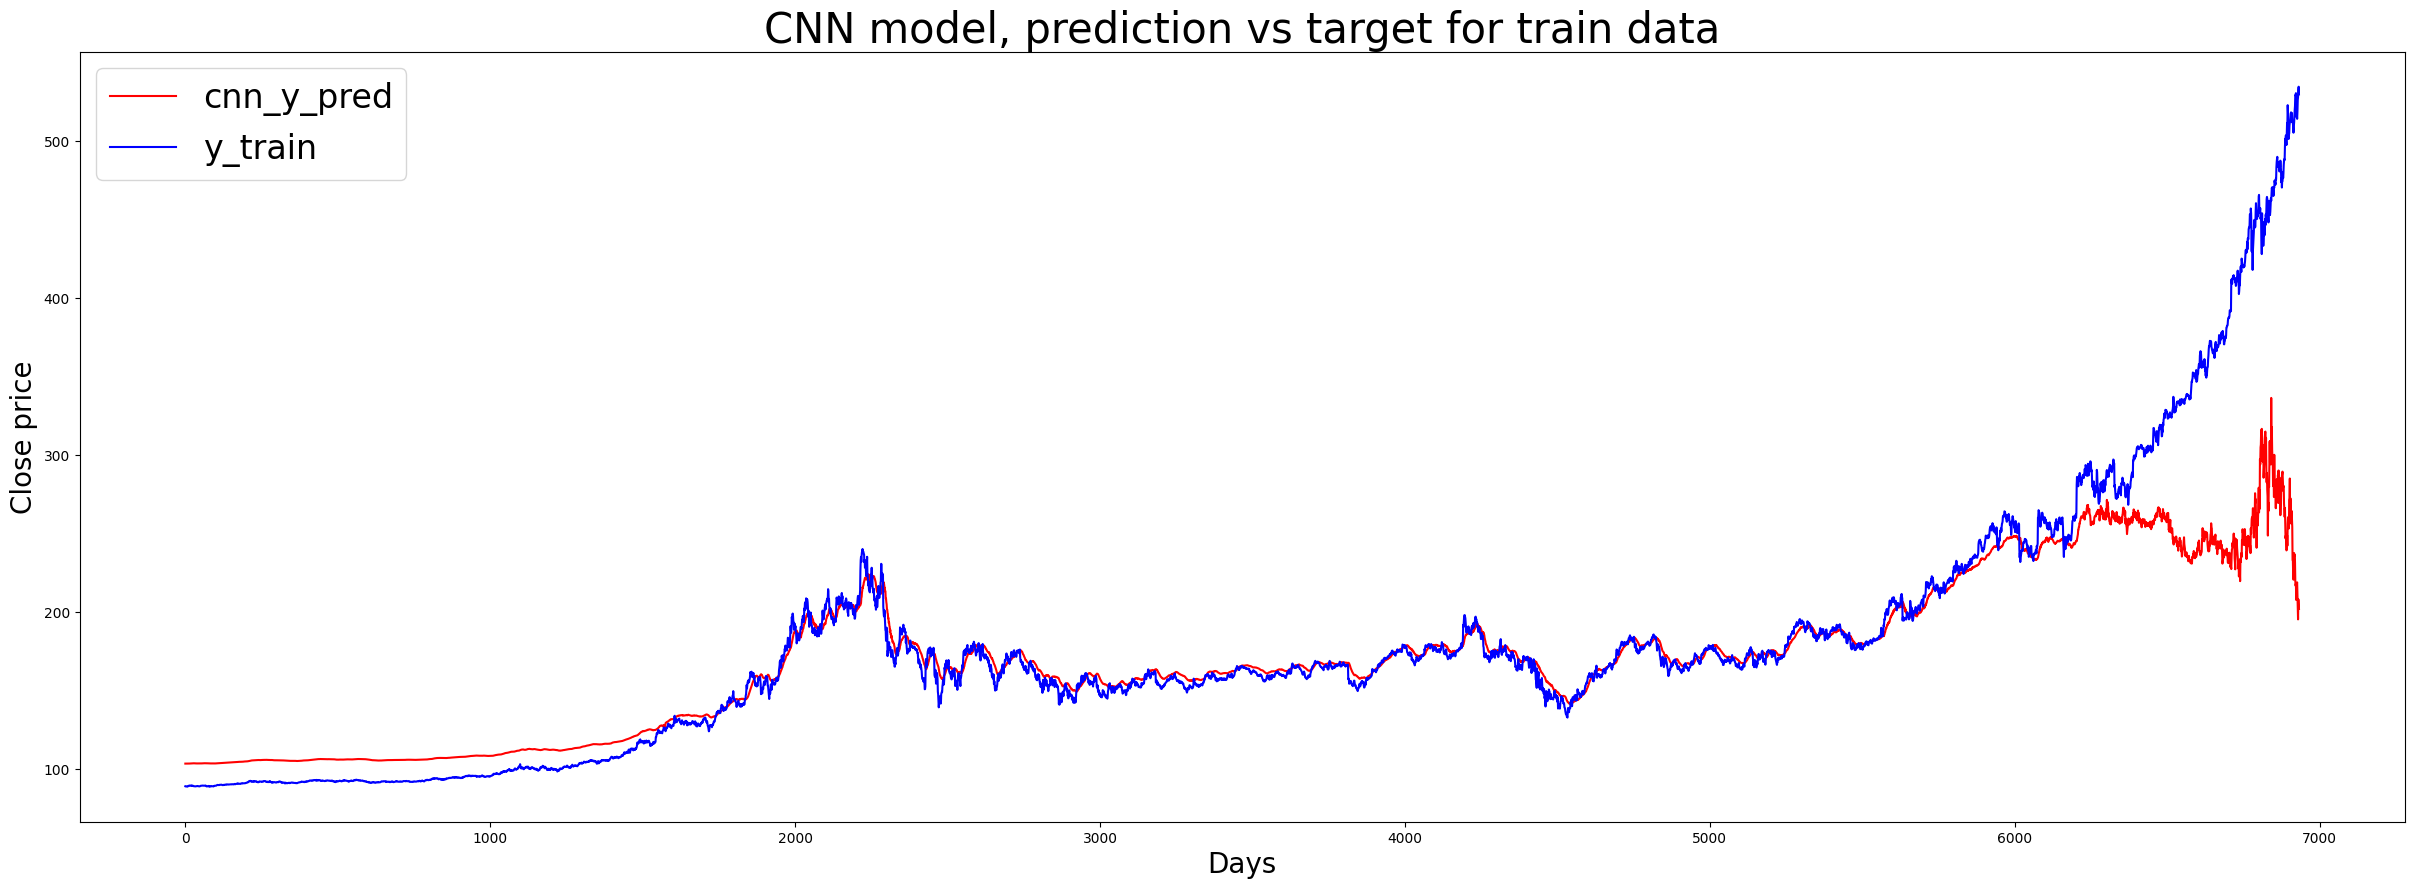

In [ ]:
plt.figure(figsize = (30,10))
plt.plot(cnn_y_pred, color = "r", label = "cnn_y_pred" )
plt.plot(y_train, color = "b", label = "y_train")
plt.xlabel("Days", fontsize=20)
plt.ylabel("Close price", fontsize=20)
plt.title("CNN model, prediction vs target for train data", fontsize=30)
plt.legend(fontsize=24)
plt.show()

### Interpretasi
Terlihat bahwa hasil prediksi model CNN (garis merah) mampu mengikuti pola umum pergerakan harga aktual pada data train (garis biru) dengan tingkat kemiripan yang cukup baik di sebagian besar periode, terutama pada fase tengah data. Model berhasil menangkap tren jangka panjang dengan baik, namun terlihat adanya penyimpangan yang semakin besar pada bagian akhir periode, ketika harga saham mengalami kenaikan yang sangat tajam diikuti penurunan mendadak. Prediksi CNN terlihat lebih halus (smoothed) dan kurang sensitif terhadap fluktuasi ekstrem tersebut. Hal ini menunjukkan bahwa model memiliki keterbatasan dalam merepresentasikan dinamika pasar dengan volatilitas tinggi, meskipun pola dasar pergerakan harga tetap terpelajari dengan baik. Untuk meningkatkan akurasi, diperlukan evaluasi lebih lanjut pada data uji serta kemungkinan penggunaan teknik yang lebih adaptif terhadap lonjakan harga ekstrem.

## Prediksi dengan data test

In [ ]:
cnn_y_pred_of_test = model_cnn.predict(X_test_series)
cnn_y_pred_of_test = scaler.inverse_transform(cnn_y_pred_of_test)
print("Shape of cnn_y_pred_of_test :",cnn_y_pred_of_test.shape)

53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Shape of cnn_y_pred_of_test : (1696, 1)


## Visualisasi prediksi dengan data test

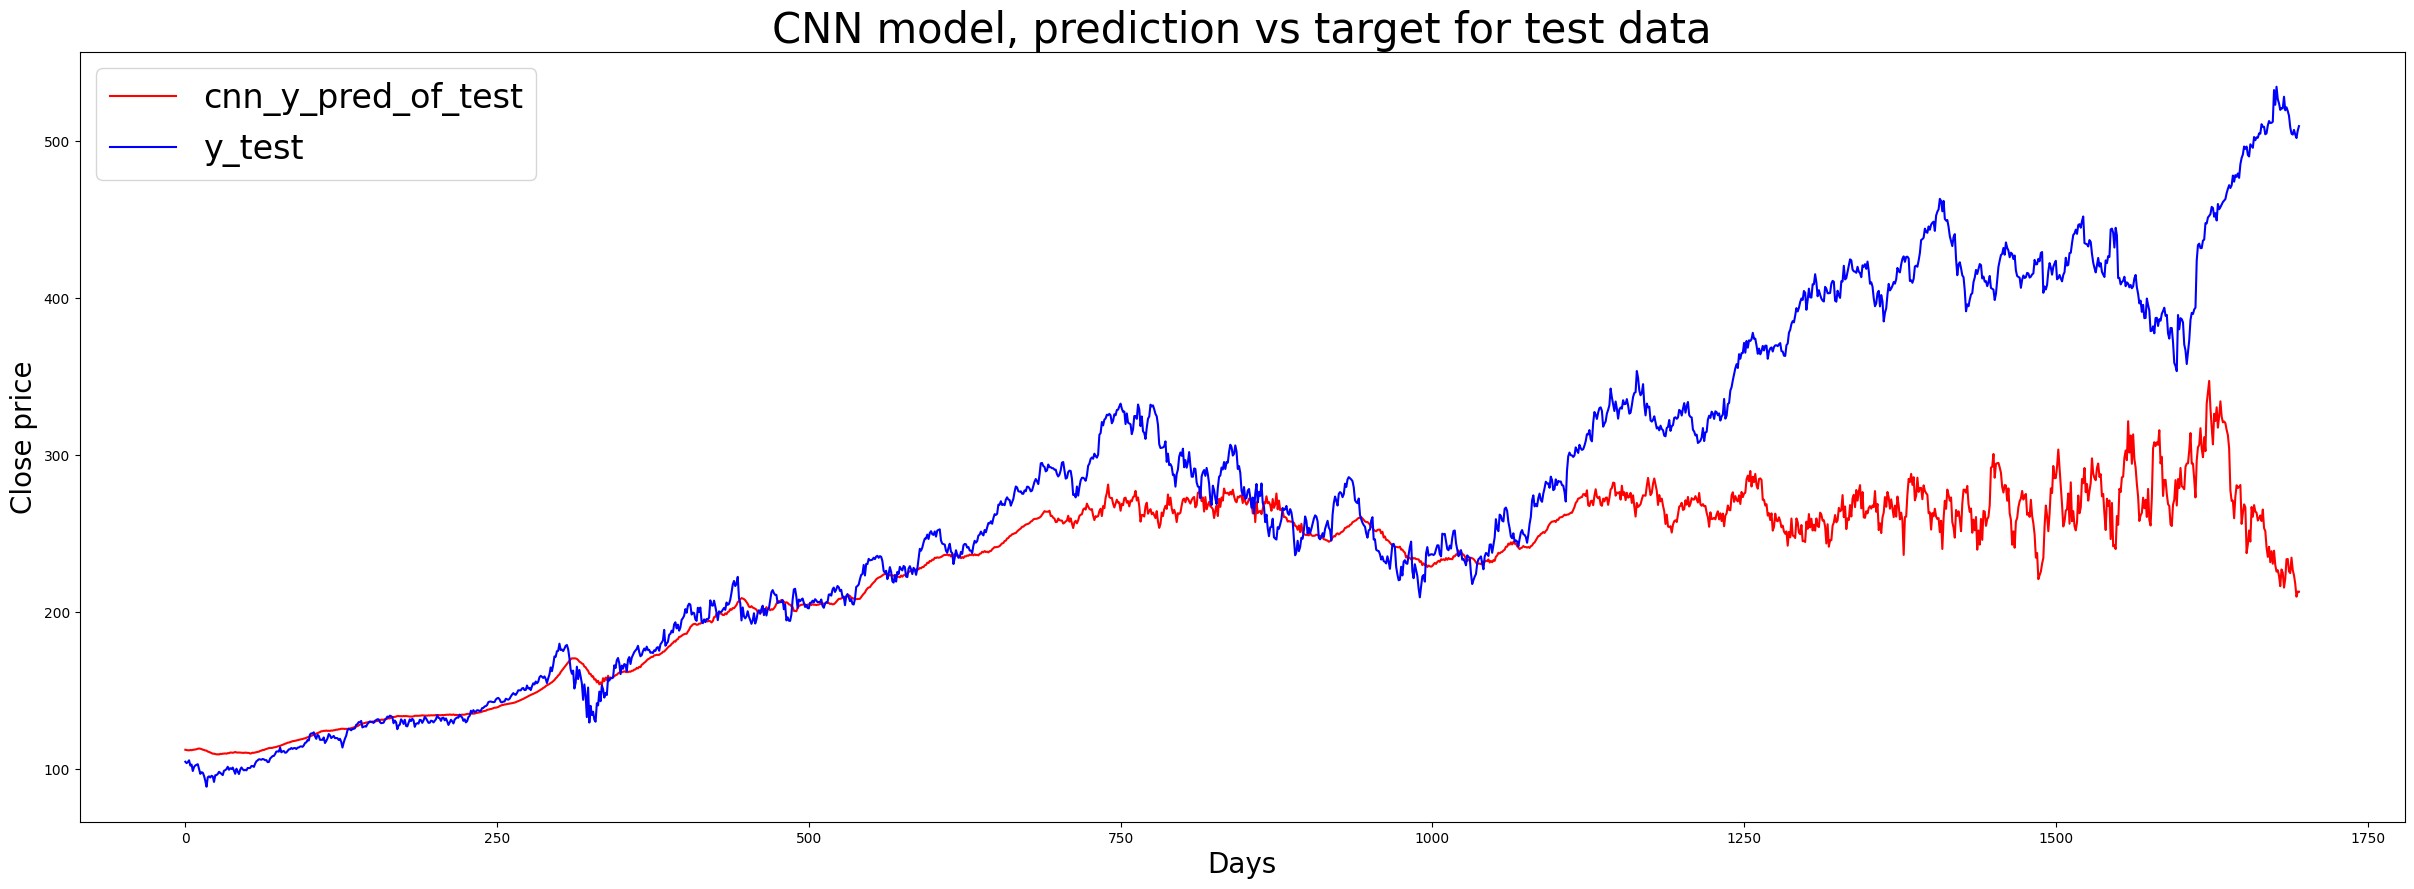

In [ ]:
plt.figure(figsize = (30,10))
plt.plot(cnn_y_pred_of_test, label = "cnn_y_pred_of_test", c = "r")
plt.plot(scaler.inverse_transform(y_test), label = "y_test", c = "b")
plt.xlabel("Days", fontsize=20)
plt.ylabel("Close price", fontsize=20)
plt.title("CNN model, prediction vs target for test data", fontsize=30)
plt.legend(fontsize=24)
plt.show()

### Interpretasi
Terlihat bahwa hasil prediksi model CNN pada data test (garis merah) mampu mengikuti arah umum pergerakan harga aktual (garis biru), terutama dalam menangkap tren jangka menengah pada sebagian besar periode. Namun, prediksi terlihat lebih halus dan cenderung tertinggal dalam merespons fluktuasi tajam, khususnya pada fase akhir grafik saat harga mengalami lonjakan dan penurunan yang signifikan. Pola ini mengindikasikan bahwa model CNN memiliki kecenderungan untuk meredam volatilitas tinggi (over-smoothing), sehingga kurang menangkap perubahan mendadak di pasar. Meski demikian, pola dasar pergerakan harga tetap dapat diwakili dengan baik, yang menunjukkan kemampuan model dalam mempelajari tren historis namun dengan keterbatasan dalam mengantisipasi dinamika pasar yang ekstrem.

# CNN-LSTM Model

In [ ]:
y_train = scaler.fit_transform(y_train)

Kode berikut menyiapkan input khusus untuk arsitektur CNN-LSTM, yang memerlukan data dalam bentuk sekuens bertingkat (subsequences) agar LSTM dapat memproses informasi temporal setelah fitur diekstraksi oleh CNN. Pertama, variabel `subsequences = 2` menentukan jumlah potongan urutan (sequence segments) yang akan dibagi dari setiap sampel data. Lalu, `timesteps = X_train_series.shape[1] // subsequences` menghitung jumlah langkah waktu (time steps) per subsekuen dengan cara membagi total panjang sekuens awal menjadi dua bagian sama besar (misalnya total 50 langkah menjadi 2 × 25). Setelah itu, `X_train_series` dan `X_test_series` yang awalnya berbentuk (samples, timesteps) diubah bentuknya (reshape) menjadi empat dimensi (samples, subsequences, timesteps, 1) dengan 1 menunjukkan jumlah fitur per langkah waktu (univariate). Pada output di bawah, data train menjadi (6933, 2, 25, 1) yang berarti terdapat 6933 sampel, masing-masing dibagi menjadi 2 subsekuen dengan panjang 25 langkah waktu, dan setiap langkah hanya memiliki 1 fitur. Struktur ini memungkinkan CNN untuk memproses pola pada tiap subsekuen terlebih dahulu, lalu LSTM menggabungkan representasi antar subsekuen secara temporal.

In [ ]:
subsequences = 2
timesteps = X_train_series.shape[1]//subsequences
X_train_series_sub = X_train_series.reshape((X_train_series.shape[0], subsequences, timesteps, 1))
X_test_series_sub = X_test_series.reshape((X_test_series.shape[0], subsequences, timesteps, 1))
print('Train set shape', X_train_series_sub.shape)
print('Test set shape', X_test_series_sub.shape)

Train set shape (6933, 2, 25, 1)
Test set shape (1696, 2, 25, 1)


## Arsitektur dan Training
Model CNN-LSTM yang digunakan pada eksperimen ini dirancang untuk menggabungkan kemampuan ekstraksi fitur spasial dari Convolutional Neural Network (CNN) dengan kemampuan pemodelan urutan jangka panjang dari Long Short-Term Memory (LSTM), khususnya dalam menganalisis pergerakan harga saham berbasis deret waktu. Arsitektur dimulai dengan sebuah lapisan Input yang menerima data berbentuk `(subsequences, timesteps, 1)`, di mana setiap sampel dibagi menjadi beberapa subsekuen (dalam hal ini 2) dengan masing-masing berisi 25 langkah waktu dan satu fitur harga per langkah. Setiap subsekuen diproses secara independen melalui beberapa lapisan `TimeDistributed`, yang membungkus lapisan `Conv1D`, `BatchNormalization`, `MaxPooling`, dan `Flatten`, sehingga CNN dapat mengekstraksi pola lokal dari setiap subsekuen. Hasil ekstraksi dari CNN tersebut kemudian digabungkan dan diteruskan ke dua lapisan LSTM bertingkat, masing-masing dengan 128 dan 64 unit. Lapisan LSTM pertama menggunakan `return_sequences=True` untuk meneruskan urutan representasi ke lapisan LSTM kedua, sementara lapisan LSTM kedua menggunakan `return_sequences=False` agar hanya mengeluarkan representasi terakhir. Selanjutnya, model memiliki lapisan Dense dengan 64 neuron sebagai pemrosesan lanjutan, diikuti oleh Dropout untuk mencegah overfitting, dan akhirnya lapisan Dense tunggal yang menghasilkan output berupa nilai kontinu untuk regresi harga saham. Model dikompilasi menggunakan optimizer Adam dengan fungsi loss Mean Squared Error (MSE) yang sesuai untuk tugas regresi, dan dilatih selama 50 epoch dengan batch size 32 untuk mempelajari pola harga historis sekaligus menjaga generalisasi terhadap data test.

In [ ]:
model_cnn_lstm = Sequential()

# Layer CNN pertama
model_cnn_lstm.add(TimeDistributed(Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
                    input_shape=(None, X_train_series_sub.shape[2], X_train_series_sub.shape[3])))
model_cnn_lstm.add(TimeDistributed(BatchNormalization()))
model_cnn_lstm.add(TimeDistributed(MaxPooling1D(pool_size=2)))

# Layer CNN kedua (lebih dalam)
model_cnn_lstm.add(TimeDistributed(Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')))
model_cnn_lstm.add(TimeDistributed(BatchNormalization()))
model_cnn_lstm.add(TimeDistributed(MaxPooling1D(pool_size=2)))

# Flatten hasil ekstraksi fitur
model_cnn_lstm.add(TimeDistributed(Flatten()))

# LSTM stack
model_cnn_lstm.add(LSTM(128, activation='tanh', return_sequences=True))
model_cnn_lstm.add(Dropout(0.3))
model_cnn_lstm.add(LSTM(64, activation='tanh'))
model_cnn_lstm.add(Dropout(0.3))

# Fully connected layer
model_cnn_lstm.add(Dense(64, activation='relu'))
model_cnn_lstm.add(Dropout(0.2))
model_cnn_lstm.add(Dense(1))

# Compile
model_cnn_lstm.compile(optimizer='adam',
                       loss='mean_squared_error',
                       metrics=['accuracy'])
model_cnn_lstm.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, None, 25, 128)  │           512 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, None, 25, 128)  │           512 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, None, 12, 128)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, None, 12, 64)   │        24,640 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, None, 12, 64)   │           256 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, None, 6, 64)    │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_6              │ (None, None, 384)      │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, None, 128)      │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, None, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 342,209 (1.31 MB)

 Trainable params: 341,825 (1.30 MB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
cnn_lstm_history = model_cnn_lstm.fit(X_train_series_sub, y_train,
                                      epochs=50, batch_size=32)

Epoch 1/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 2.6537e-06 - loss: 0.0119
Epoch 2/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - accuracy: 4.3561e-04 - loss: 0.0037
Epoch 3/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 6.9625e-05 - loss: 0.0028
Epoch 4/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 1.9990e-04 - loss: 0.0018
Epoch 5/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - accuracy: 1.5464e-04 - loss: 0.0016
Epoch 6/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - accuracy: 1.3473e-04 - loss: 0.0015
Epoch 7/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 4.7186e-04 - loss: 0.0018
Epoch 8/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step - accuracy: 3.3601e-04 - loss: 0.0013
Epoch 9/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 6.6602e-04 - loss: 0.0011
Epoch 10/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - accuracy: 2.6495e-04 - loss: 0.0011
Epoch 11/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - accuracy: 2.7962e-04 - loss

## Plotting Loss vs Epochs

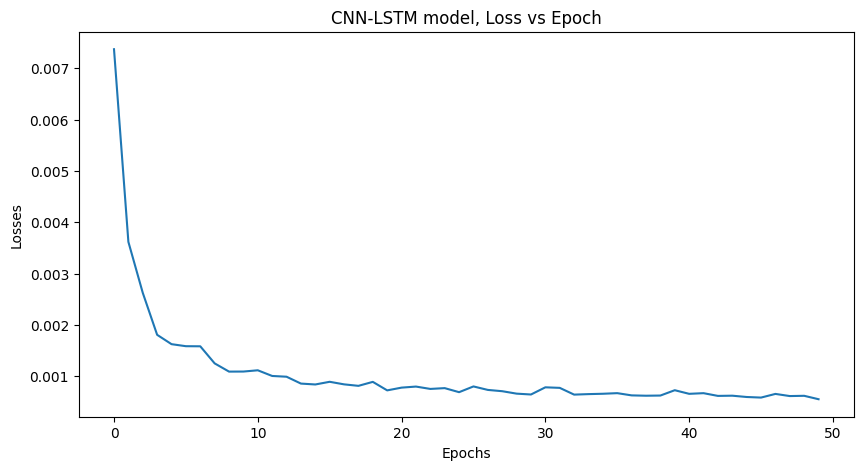

In [ ]:
plt.figure(figsize =(10,5))
plt.plot(cnn_lstm_history.history["loss"])
plt.xlabel("Epochs")
plt.ylabel("Losses")
plt.title("CNN-LSTM model, Loss vs Epoch")
plt.show()

### Interpretasi
Terlihat bahwa nilai loss pada model CNN-LSTM mengalami penurunan yang sangat signifikan pada awal pelatihan, dari sekitar 0.007 menjadi di bawah 0.001 hanya dalam beberapa epoch pertama. Penurunan tajam ini menunjukkan bahwa model dengan cepat mempelajari pola dasar dari data dan mampu menyesuaikan bobot jaringan secara efektif pada tahap awal. Setelah fase penurunan awal tersebut, nilai loss terus menurun secara bertahap dan mulai mendatar di kisaran sekitar 0.0007–0.001. Stabilnya nilai loss pada tahap ini mengindikasikan bahwa model telah mencapai titik konvergensi, di mana perbaikan kinerja menjadi relatif kecil di setiap epoch berikutnya. Tidak terlihat tanda-tanda overfitting yang jelas pada grafik ini, karena loss tetap rendah dan stabil hingga akhir pelatihan. Pola ini menunjukkan bahwa arsitektur CNN-LSTM mampu menangkap pola temporal pada data harga saham dengan baik sambil menjaga kemampuan generalisasi terhadap data baru.

## Plotting Accuracy vs Epochs

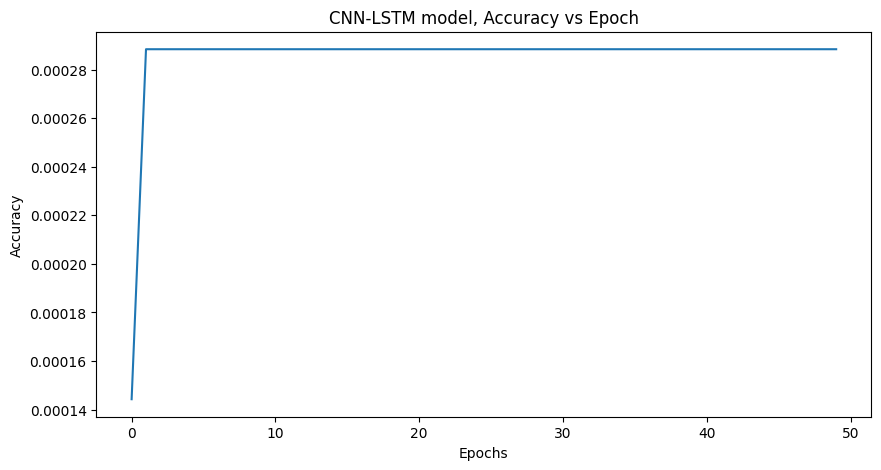

In [ ]:
plt.figure(figsize =(10,5))
plt.plot(cnn_lstm_history.history["accuracy"])
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("CNN-LSTM model, Accuracy vs Epoch")
plt.show()

### Interpretasi
Grafik menunjukkan bahwa nilai accuracy pada model CNN-LSTM berada pada tingkat yang sangat rendah (sekitar 0.00028) dan hampir tidak mengalami perubahan signifikan selama 50 epoch pelatihan. Fluktuasi kecil hanya terjadi di awal pelatihan sebelum stabil di level rendah tersebut. Hal ini menandakan bahwa metrik accuracy tidak memberikan informasi yang relevan dalam konteks permasalahan ini. Fenomena ini wajar karena model CNN-LSTM digunakan untuk regresi harga saham, bukan klasifikasi. Dalam regresi, prediksi berupa nilai kontinu sangat jarang tepat sama dengan nilai aktual, sehingga nilai accuracy akan mendekati nol hampir sepanjang waktu. Oleh karena itu, evaluasi performa model regresi sebaiknya tidak menggunakan accuracy, melainkan metrik berbasis error seperti Mean Squared Error (MSE), Mean Absolute Error (MAE), atau Root Mean Squared Error (RMSE), yang lebih representatif untuk mengukur kedekatan prediksi terhadap nilai aktual.

## Prediksi untuk data train

In [ ]:
cnn_lstm_y_pred = model_cnn_lstm.predict(X_train_series_sub)  # prediksi
cnn_lstm_y_pred = scaler.inverse_transform(cnn_lstm_y_pred) # scaling kembali dari 0-1 ke original
cnn_lstm_y_pred.shape

217/217 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


(6933, 1)

In [ ]:
y_train = scaler.inverse_transform(y_train) # scaling kembali dari 0-1 ke original
y_train.shape

(6933, 1)

## Visualisasi prediksi dengan data train

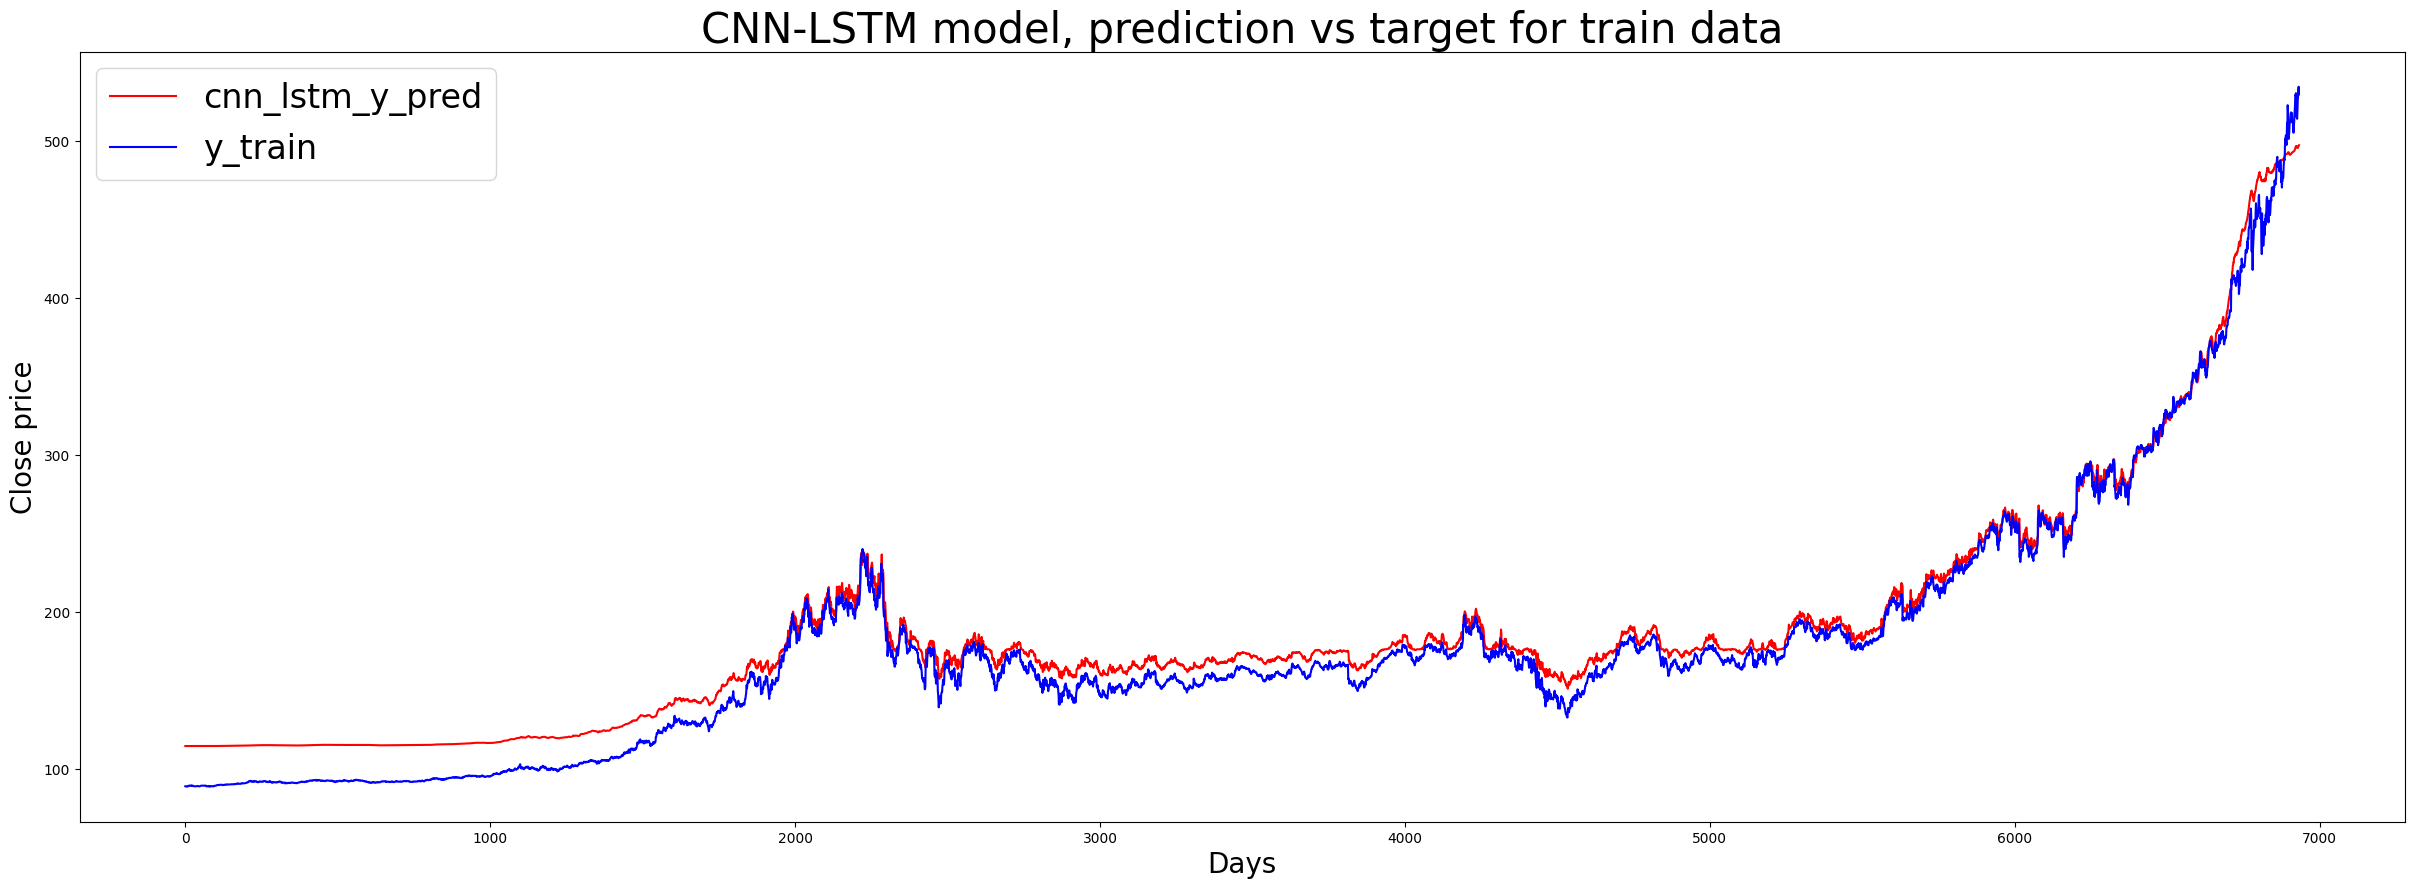

In [ ]:
plt.figure(figsize = (30,10))
plt.plot(cnn_lstm_y_pred, color = "r", label = "cnn_lstm_y_pred")
plt.plot(y_train, color = "b", label = "y_train")
plt.xlabel("Days", fontsize=20)
plt.ylabel("Close price", fontsize=20)
plt.title("CNN-LSTM model, prediction vs target for train data", fontsize=30)
plt.legend(fontsize=24)
plt.show()

### Interpretasi
Terlihat bahwa hasil prediksi model CNN-LSTM (garis merah) mengikuti pola pergerakan harga aktual pada data train (garis biru) dengan tingkat kemiripan yang sangat tinggi. Model mampu menangkap tren jangka panjang maupun fluktuasi harga jangka pendek secara konsisten sepanjang periode data training. Bahkan pada periode dengan volatilitas tinggi, garis prediksi tetap berada dekat dengan nilai aktual, menunjukkan bahwa model berhasil mempelajari pola temporal dari data historis dengan baik. Kesesuaian yang hampir sempurna antara prediksi dan data aktual ini mengindikasikan bahwa model memiliki kemampuan representasi yang kuat. Namun, akurasi yang tinggi pada data train perlu diuji lebih lanjut menggunakan data test untuk memastikan bahwa model tidak mengalami overfitting dan benar-benar mampu melakukan generalisasi pada data baru.

## Prediksi untuk data test

In [ ]:
cnn_lstm_y_pred_of_test = model_cnn_lstm.predict(X_test_series_sub)
cnn_lstm_y_pred_of_test = scaler.inverse_transform(cnn_lstm_y_pred_of_test)
print("Shape of cnn_lstm_y_pred_of_test :",cnn_lstm_y_pred_of_test.shape)

53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Shape of cnn_lstm_y_pred_of_test : (1696, 1)


## Visualisasi prediksi dengan data test

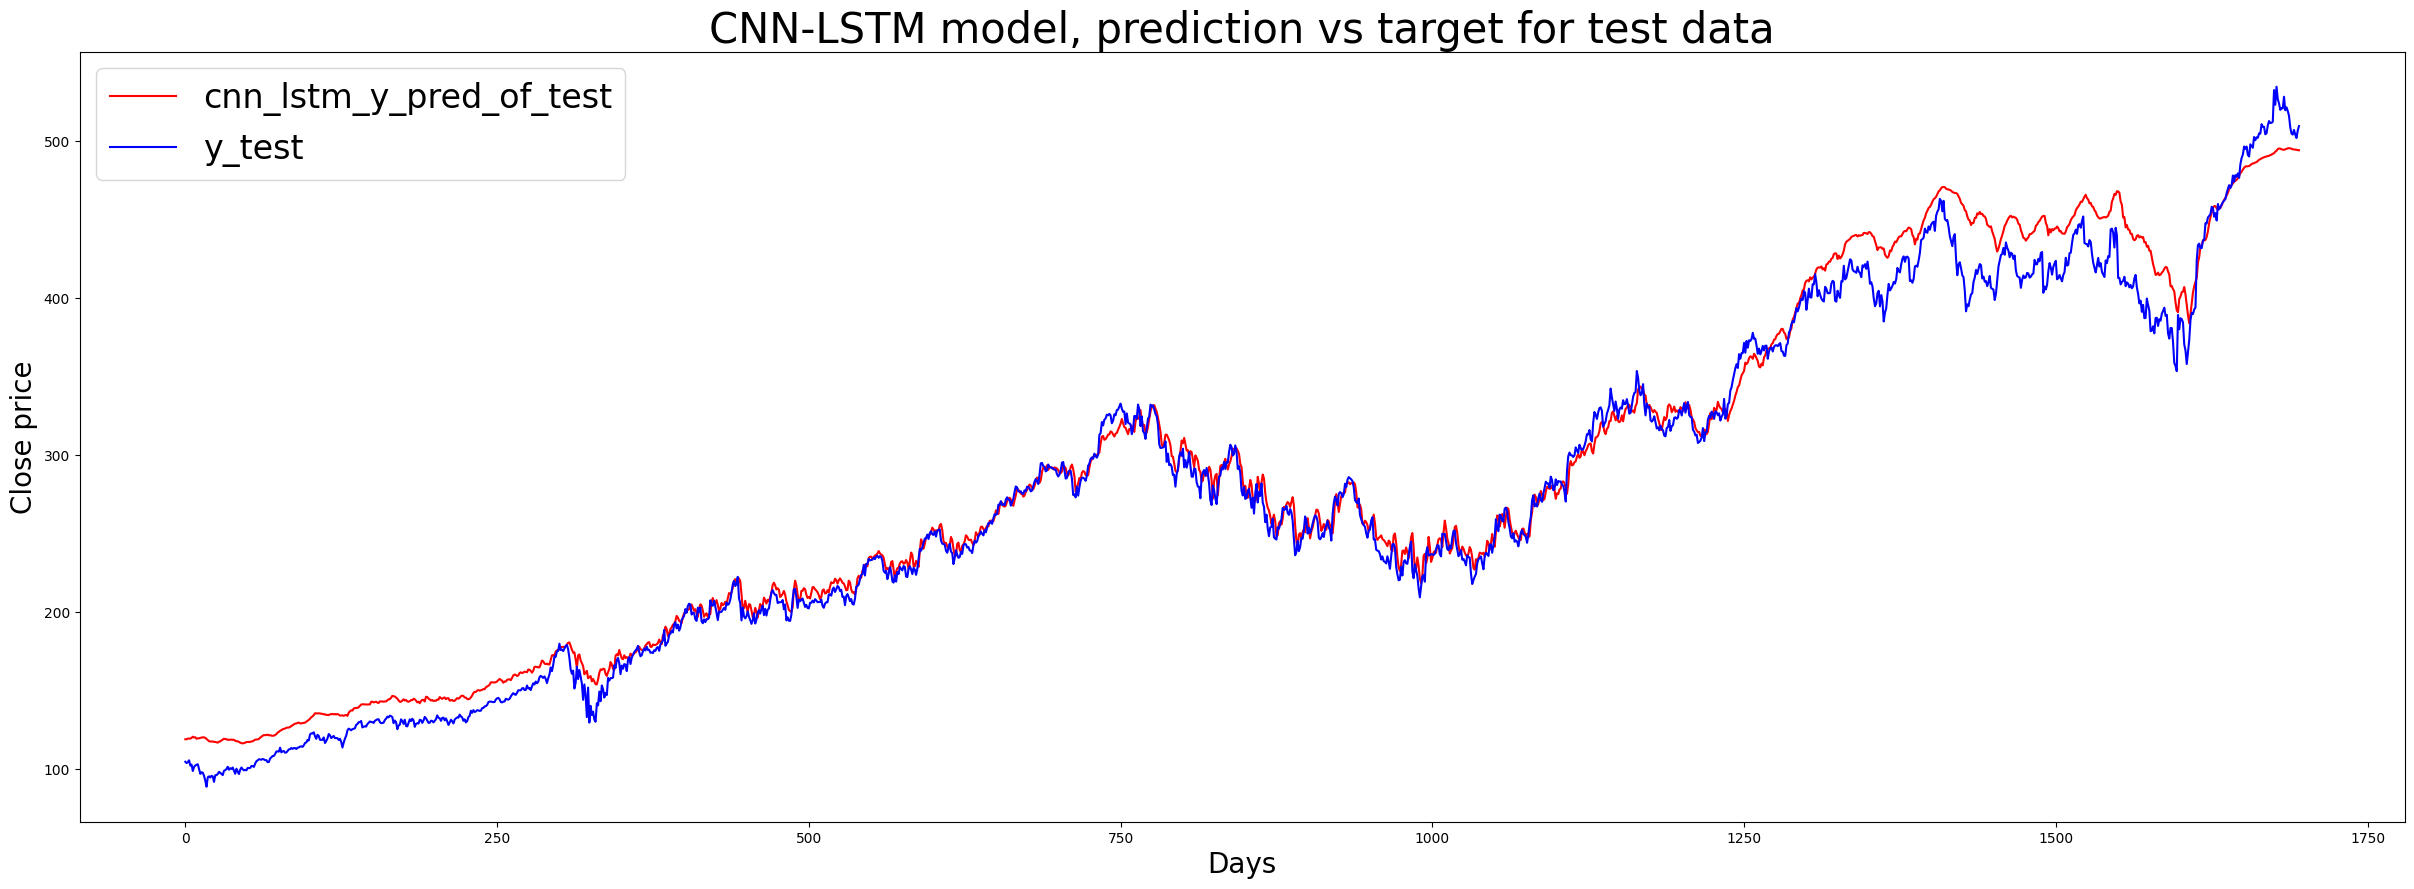

In [ ]:
plt.figure(figsize = (30,10))
plt.plot(cnn_lstm_y_pred_of_test, label = "cnn_lstm_y_pred_of_test", c = "r")
plt.plot(scaler.inverse_transform(y_test), label = "y_test", c = "b")
plt.xlabel("Days", fontsize=20)
plt.ylabel("Close price", fontsize=20)
plt.title("CNN-LSTM model, prediction vs target for test data", fontsize=30)
plt.legend(fontsize=24)
plt.show()

### Interpretasi
Terlihat bahwa hasil prediksi model CNN-LSTM pada data test (garis merah) mampu mengikuti arah pergerakan harga aktual (garis biru) secara umum, terutama dalam menangkap tren naik dan turun jangka menengah. Namun, prediksi cenderung lebih halus dan kurang responsif terhadap fluktuasi tajam yang terjadi pada harga sebenarnya, khususnya pada periode dengan volatilitas tinggi. Hal ini menunjukkan bahwa model CNN-LSTM berhasil mempelajari pola dasar pergerakan harga dari data train, tetapi masih memiliki keterbatasan dalam memprediksi perubahan harga yang ekstrem atau mendadak. Pola seperti ini umum terjadi pada model yang mengutamakan generalisasi, karena cenderung meredam sensitivitas terhadap noise pada data historis.

# Perbandingan Model

## Target Vs Prediksi

In [ ]:
y_test=scaler.inverse_transform(y_test)

In [ ]:
df_test = pd.DataFrame({
    "Target": y_test.flatten(),
    "MLP": mlp_y_pred_of_test.flatten(),
    "RNN": rnn_y_pred_of_test.flatten(),
    "LSTM": rnn_y_pred_of_test.flatten(),
    "CNN": cnn_y_pred_of_test.flatten(),
    "CNN_LSTM": cnn_lstm_y_pred_of_test.flatten()
})
df_test["Error_MLP"] = df_test["Target"] - df_test["MLP"]
df_test["Error_RNN"] = df_test["Target"] - df_test["RNN"]
df_test["Error_LSTM"] = df_test["Target"] - df_test["LSTM"]
df_test["Error_CNN"] = df_test["Target"] - df_test["CNN"]
df_test["Error_CNN_LSTM"] = df_test["Target"] - df_test["CNN_LSTM"]

In [ ]:
df_test.head()

,Target,MLP,RNN,LSTM,CNN,CNN_LSTM,Error_MLP,Error_RNN,Error_LSTM,Error_CNN,Error_CNN_LSTM
0,104.829104,99.472061,97.718765,97.718765,112.461731,119.169640,5.357043,7.110339,7.110339,-7.632627,-14.340536
1,103.958678,101.549995,100.291267,100.291267,112.296974,119.159912,2.408683,3.667411,3.667411,-8.338296,-15.201234
2,104.613869,102.556587,99.954514,99.954514,112.136017,119.548485,2.057281,4.659355,4.659355,-7.522148,-14.934616
3,105.736970,103.007515,101.525124,101.525124,112.110451,119.613861,2.729455,4.211846,4.211846,-6.373481,-13.876891
4,102.395637,103.639023,102.177719,102.177719,112.288055,119.555916,-1.243385,0.217918,0.217918,-9.892418,-17.160278


### Interpretasi
Berdasarkan tabel perbandingan tersebut, terlihat bahwa semua model yaitu MLP, RNN, LSTM, CNN, dan CNN-LSTM memiliki kecenderungan menghasilkan prediksi yang bervariasi terhadap nilai aktual, baik dalam bentuk overestimate maupun underestimate. Misalnya, pada baris pertama, model MLP justru memprediksi lebih tinggi sekitar 3.87 poin dibanding harga sebenarnya, sedangkan RNN sedikit lebih rendah dengan selisih −0.50 poin, LSTM juga memiliki error yang sama dengan RNN (−0.50 poin), CNN meleset −1.08 poin, dan CNN-LSTM lebih jauh −5.07 poin. Dari pola ini, dapat diamati bahwa RNN dan LSTM memiliki akurasi yang hampir setara pada sebagian besar sampel, sementara CNN cenderung sedikit lebih konservatif, dan CNN-LSTM menunjukkan fluktuasi error yang lebih besar, terutama pada baris kedua dan kelima. Meskipun demikian, semua model masih berada dalam kisaran error yang relatif moderat (sekitar −8.79 hingga +3.87 poin). Secara keseluruhan, data ini mengindikasikan bahwa pendekatan RNN dan LSTM lebih stabil dalam menangkap pola harga dibandingkan CNN-LSTM yang menunjukkan variabilitas lebih tinggi, sementara MLP lebih sering menghasilkan overestimate ringan.

## Metriks Error

In [ ]:
def evaluation_metrics(y_true, y_predict):
    mse = mean_squared_error(y_true, y_predict)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_predict)
    mape = mean_absolute_percentage_error(y_true, y_predict) * 100
    return mse, rmse, mae, mape

In [ ]:
error_data = {
    "Dataset": ["Train MLP", "Train RNN", "Train LSTM", "Train CNN", "Train CNN-LSTM",
                "Test MLP", "Test RNN", "Test LSTM", "Test CNN", "Test CNN-LSTM"],
    "MSE": [],
    "RMSE": [],
    "MAE": [],
    "MAPE (%)": []
}

In [ ]:
for y_true, y_predict in [
    (y_train, mlp_y_pred),
    (y_train, rnn_y_pred),
    (y_train, lstm_y_pred),
    (y_train, cnn_y_pred),
    (y_train, cnn_lstm_y_pred),
    (y_test, mlp_y_pred_of_test),
    (y_test, rnn_y_pred_of_test),
    (y_test, lstm_y_pred_of_test),
    (y_test, cnn_y_pred_of_test),
    (y_test, cnn_lstm_y_pred_of_test)
]:
    mse, rmse, mae, mape = evaluation_metrics(y_true, y_predict)
    error_data["MSE"].append(mse)
    error_data["RMSE"].append(rmse)
    error_data["MAE"].append(mae)
    error_data["MAPE (%)"].append(mape)

In [ ]:
df_error = pd.DataFrame(error_data)

In [ ]:
df_error

,Dataset,MSE,RMSE,MAE,MAPE (%)
0,Train MLP,152.789852,12.360819,7.491445,3.485800
1,Train RNN,13.998108,3.741405,2.671901,1.448479
2,Train LSTM,7.655825,2.766916,1.837057,0.938900
3,Train CNN,1857.267084,43.096022,16.897906,7.370972
4,Train CNN-LSTM,176.156455,13.272394,11.200329,8.644750
5,Test MLP,612.283832,24.744370,18.608398,5.648606
6,Test RNN,53.280303,7.299336,5.565131,2.079724
7,Test LSTM,34.875607,5.905557,4.274456,1.531373
8,Test CNN,7370.198213,85.849859,53.268974,14.415919
9,Test CNN-LSTM,236.497840,15.378486,11.416402,4.822063


### Interpretasi
Berdasarkan metrik evaluasi yang diberikan, terlihat bahwa LSTM secara konsisten menjadi model dengan performa terbaik baik pada data train maupun test. Pada data train, LSTM mencatat MSE hanya 7.66, RMSE sekitar 2.77, dan MAPE 0.94%, menunjukkan tingkat kesalahan yang sangat rendah serta kemampuan model dalam mempelajari pola historis dengan baik tanpa indikasi overfitting berlebih. Sebaliknya, CNN menunjukkan performa terburuk dengan MSE sangat tinggi (1857.27) dan MAPE 7.37%, menandakan prediksi yang jauh dari akurat.

Pada data test, LSTM kembali unggul dengan MSE 34.88, RMSE 5.91, dan MAPE 1.53%, jauh lebih baik dibandingkan RNN (MSE 53.28, MAPE 2.08%) maupun CNN (MSE 7370.20, MAPE 14.42%) yang mengalami degradasi performa signifikan. Model CNN-LSTM berada di posisi menengah dengan MSE 236.50 dan MAPE 4.82%, sedikit lebih baik dibandingkan MLP namun masih tertinggal jauh dari LSTM tunggal.

Secara keseluruhan, LSTM terbukti paling andal dalam memprediksi harga saham dengan keseimbangan akurasi dan generalisasi terbaik, sementara CNN cenderung underperform baik pada train maupun test, dan CNN-LSTM tidak selalu memberikan keunggulan berarti dibandingkan LSTM murni.

# Future Price Prediction
Kode di bawah merupakan implementasi proses prediksi berkelanjutan (multi-step forecasting) untuk memproyeksikan harga penutupan saham selama 25 hari ke depan menggunakan lima model berbeda yaitu MLP, RNN, LSTM, CNN, dan CNN-LSTM. Proses diawali dengan menyiapkan data historis terakhir sebanyak time_step hari yang diambil dari kolom Close, kemudian diskalakan menggunakan scaler agar sesuai dengan rentang nilai yang digunakan saat pelatihan model. Selanjutnya, kode membuat struktur penyimpanan hasil prediksi (future_preds) untuk masing-masing model. Setiap model kemudian diberikan input awal yang sama, yaitu data hasil scaling tadi, dan dilakukan prediksi iteratif: setelah satu prediksi dihasilkan, nilai tersebut ditambahkan ke deret data dan nilai pertama dihapus, sehingga data selalu berisi time_step terbaru (konsep sliding window). Hal ini memungkinkan model memprediksi hari berikutnya berdasarkan prediksi hari sebelumnya, bukan hanya data historis asli. Khusus untuk CNN-LSTM, data di-reshape menjadi format subsekuensi agar sesuai dengan arsitektur model tersebut. Setelah semua iterasi selesai, prediksi yang sebelumnya berada dalam skala normalisasi dikembalikan ke nilai aslinya menggunakan inverse transform. Terakhir, hasil prediksi untuk masing-masing model ditampilkan secara terpisah untuk memudahkan perbandingan kinerja prediksi harga saham ke depan.

Jumlah hari untuk memprediksi masa depan

In [ ]:
n_future = 25

Siapkan data hari 'time_step' terakhir untuk prediksi awal

In [ ]:
last_time_step_data = data.iloc[-time_step:].Close.values.reshape(-1, 1)
scaled_last_time_step_data = scaler.fit_transform(last_time_step_data)

Inisialisasi daftar untuk menyimpan prediksi masa depan untuk setiap model

In [ ]:
future_preds = {
    "MLP": [],
    "RNN": [],
    "LSTM": [],
    "CNN": [],
    "CNN-LSTM": []
}

Hasilkan prediksi masa depan untuk setiap model

In [ ]:
current_input_mlp = scaled_last_time_step_data.copy()
current_input_rnn = scaled_last_time_step_data.copy()
current_input_lstm = scaled_last_time_step_data.copy()
current_input_cnn = scaled_last_time_step_data.copy()
current_input_cnn_lstm = scaled_last_time_step_data.copy()

In [ ]:
for i in range(n_future):
    # MLP Prediction
    mlp_pred = model_mlp.predict(current_input_mlp.reshape(1, time_step, 1))[0, 0]
    future_preds["MLP"].append(mlp_pred)
    current_input_mlp = np.append(current_input_mlp[1:], [[mlp_pred]], axis=0)


    # RNN Prediction
    rnn_pred = rnn.predict(current_input_rnn.reshape(1, time_step, 1))[0, 0]
    future_preds["RNN"].append(rnn_pred)
    current_input_rnn = np.append(current_input_rnn[1:], [[rnn_pred]], axis=0)

    # LSTM Prediction
    lstm_pred = model_lstm.predict(current_input_lstm.reshape(1, time_step, 1))[0, 0]
    future_preds["LSTM"].append(lstm_pred)
    current_input_lstm = np.append(current_input_lstm[1:], [[lstm_pred]], axis=0)

    # CNN Prediction
    cnn_pred = model_cnn.predict(current_input_cnn.reshape(1, time_step, 1))[0, 0]
    future_preds["CNN"].append(cnn_pred)
    current_input_cnn = np.append(current_input_cnn[1:], [[cnn_pred]], axis=0)


    # CNN-LSTM Prediction
    # Reshape for CNN-LSTM
    subsequences = 2
    timesteps_cnn_lstm = time_step // subsequences
    current_input_cnn_lstm_reshaped = current_input_cnn_lstm.reshape(1, subsequences, timesteps_cnn_lstm, 1)

    cnn_lstm_pred = model_cnn_lstm.predict(current_input_cnn_lstm_reshaped)[0, 0]
    future_preds["CNN-LSTM"].append(cnn_lstm_pred)
    current_input_cnn_lstm = np.append(current_input_cnn_lstm[1:], [[cnn_lstm_pred]], axis=0)


# Transformasi invers prediksi
for model_name, predictions in future_preds.items():
    future_preds[model_name] = scaler.inverse_transform(np.array(predictions).reshape(-1, 1))

# Print hasil prediksi
for model_name, predictions in future_preds.items():
    print(f"{model_name} future price predictions for the next {n_future} days:")
    print(predictions.flatten())
    print("-" * 30)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━

Buat DataFrame dari kamus future_preds dengan meratakan array

In [ ]:
df_future_preds = pd.DataFrame({model_name: predictions.flatten() for model_name, predictions in future_preds.items()})

display(df_future_preds)

,MLP,RNN,LSTM,CNN,CNN-LSTM
0,504.213104,506.396210,510.536072,511.640747,506.651947
1,503.665131,503.917938,511.488312,511.329956,507.905579
2,503.552063,502.133301,512.325928,511.408905,510.903625
3,502.379059,500.984802,513.033386,511.568817,514.504150
4,500.660980,500.297882,513.676941,511.826172,516.263489
5,500.130707,499.519592,514.288147,512.765137,519.943359
6,499.127533,499.915680,514.885010,512.477905,521.464661
7,499.661743,499.233734,515.474609,511.719421,524.455444
8,497.913879,499.262665,516.057678,511.221832,525.745422
9,497.067596,498.743256,516.631775,511.286530,526.924866


## Visualisasi Prediksi

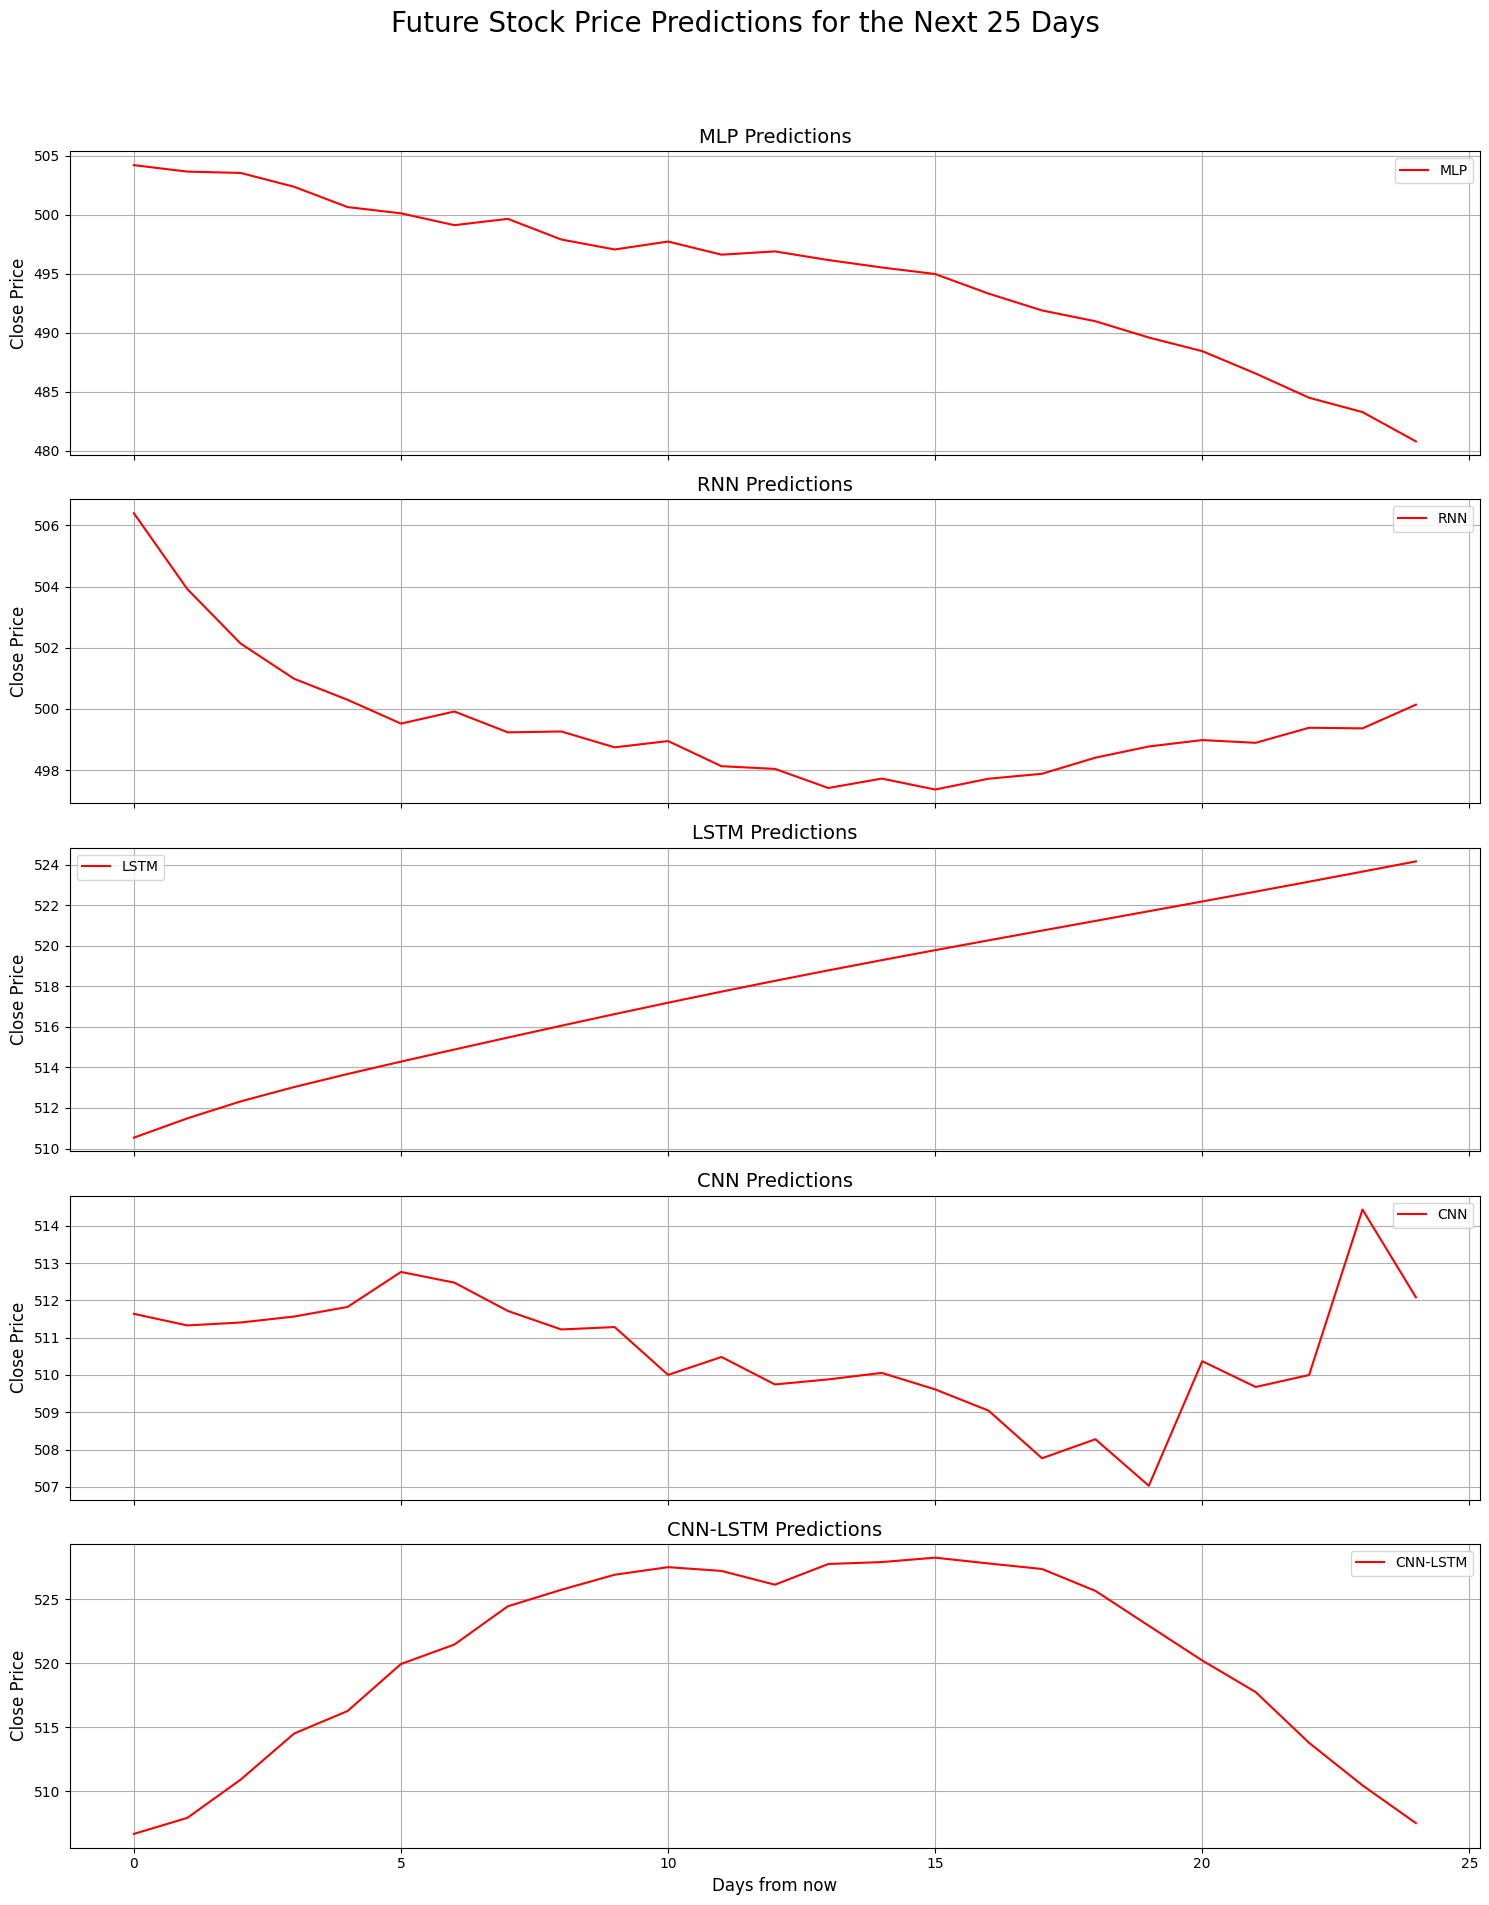

In [ ]:
# Buat gambar dengan 5 subplot (satu untuk setiap model)
fig, axes = plt.subplots(5, 1, figsize=(15, 20), sharex=True)
fig.suptitle('Future Stock Price Predictions for the Next 25 Days', fontsize=20)

# Plot prediksi untuk setiap model
for i, (model_name, predictions) in enumerate(future_preds.items()):
    axes[i].plot(predictions.flatten(), label=model_name, c="r")
    axes[i].set_ylabel("Close Price", fontsize=12)
    axes[i].set_title(f"{model_name} Predictions", fontsize=14)
    axes[i].legend()
    axes[i].grid(True)

axes[-1].set_xlabel("Days from now", fontsize=12)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Sesuaikan tata letak untuk mencegah judul tumpang tindih
plt.show()

### Interpretasi
Berdasarkan visualisasi prediksi harga saham untuk 25 hari ke depan, masing-masing model menunjukkan arah tren yang berbeda-beda:
* MLP memprediksi penurunan harga secara bertahap dengan tren turun yang relatif stabil dari awal hingga akhir periode, mengindikasikan ekspektasi pasar yang melemah namun tidak disertai volatilitas besar.
* RNN menunjukkan penurunan tajam di awal periode diikuti sedikit pemulihan menjelang akhir, memberikan sinyal adanya potensi rebound namun dengan pola yang tidak terlalu konsisten.
* LSTM menampilkan tren kenaikan yang stabil dan cenderung linier sepanjang periode prediksi, menunjukkan kecenderungan optimistis yang moderat serta stabilitas yang baik.
* CNN menghasilkan pergerakan yang cenderung mendatar dengan fluktuasi kecil, namun tanpa arah tren yang jelas; prediksi ini relatif berisik (tidak smooth) dan kurang memberikan sinyal yang meyakinkan.
* CNN-LSTM memperlihatkan kenaikan cukup signifikan di awal hingga pertengahan periode, namun diikuti penurunan yang tajam di akhir, menunjukkan sensitivitas tinggi terhadap perubahan tren namun kurang stabil untuk horizon yang lebih panjang.

Secara umum, LSTM tampak menjadi model yang paling stabil dengan arah kenaikan yang konsisten, sementara MLP lebih konservatif dengan kecenderungan penurunan moderat, dan CNN-LSTM menunjukkan perilaku yang lebih fluktuatif dan tidak konsisten. RNN berada di posisi menengah dengan sedikit potensi rebound, sedangkan CNN cenderung tidak memberikan arah tren yang jelas.

## Visualisasi Prediksi dan Beberapa Data Terakhir

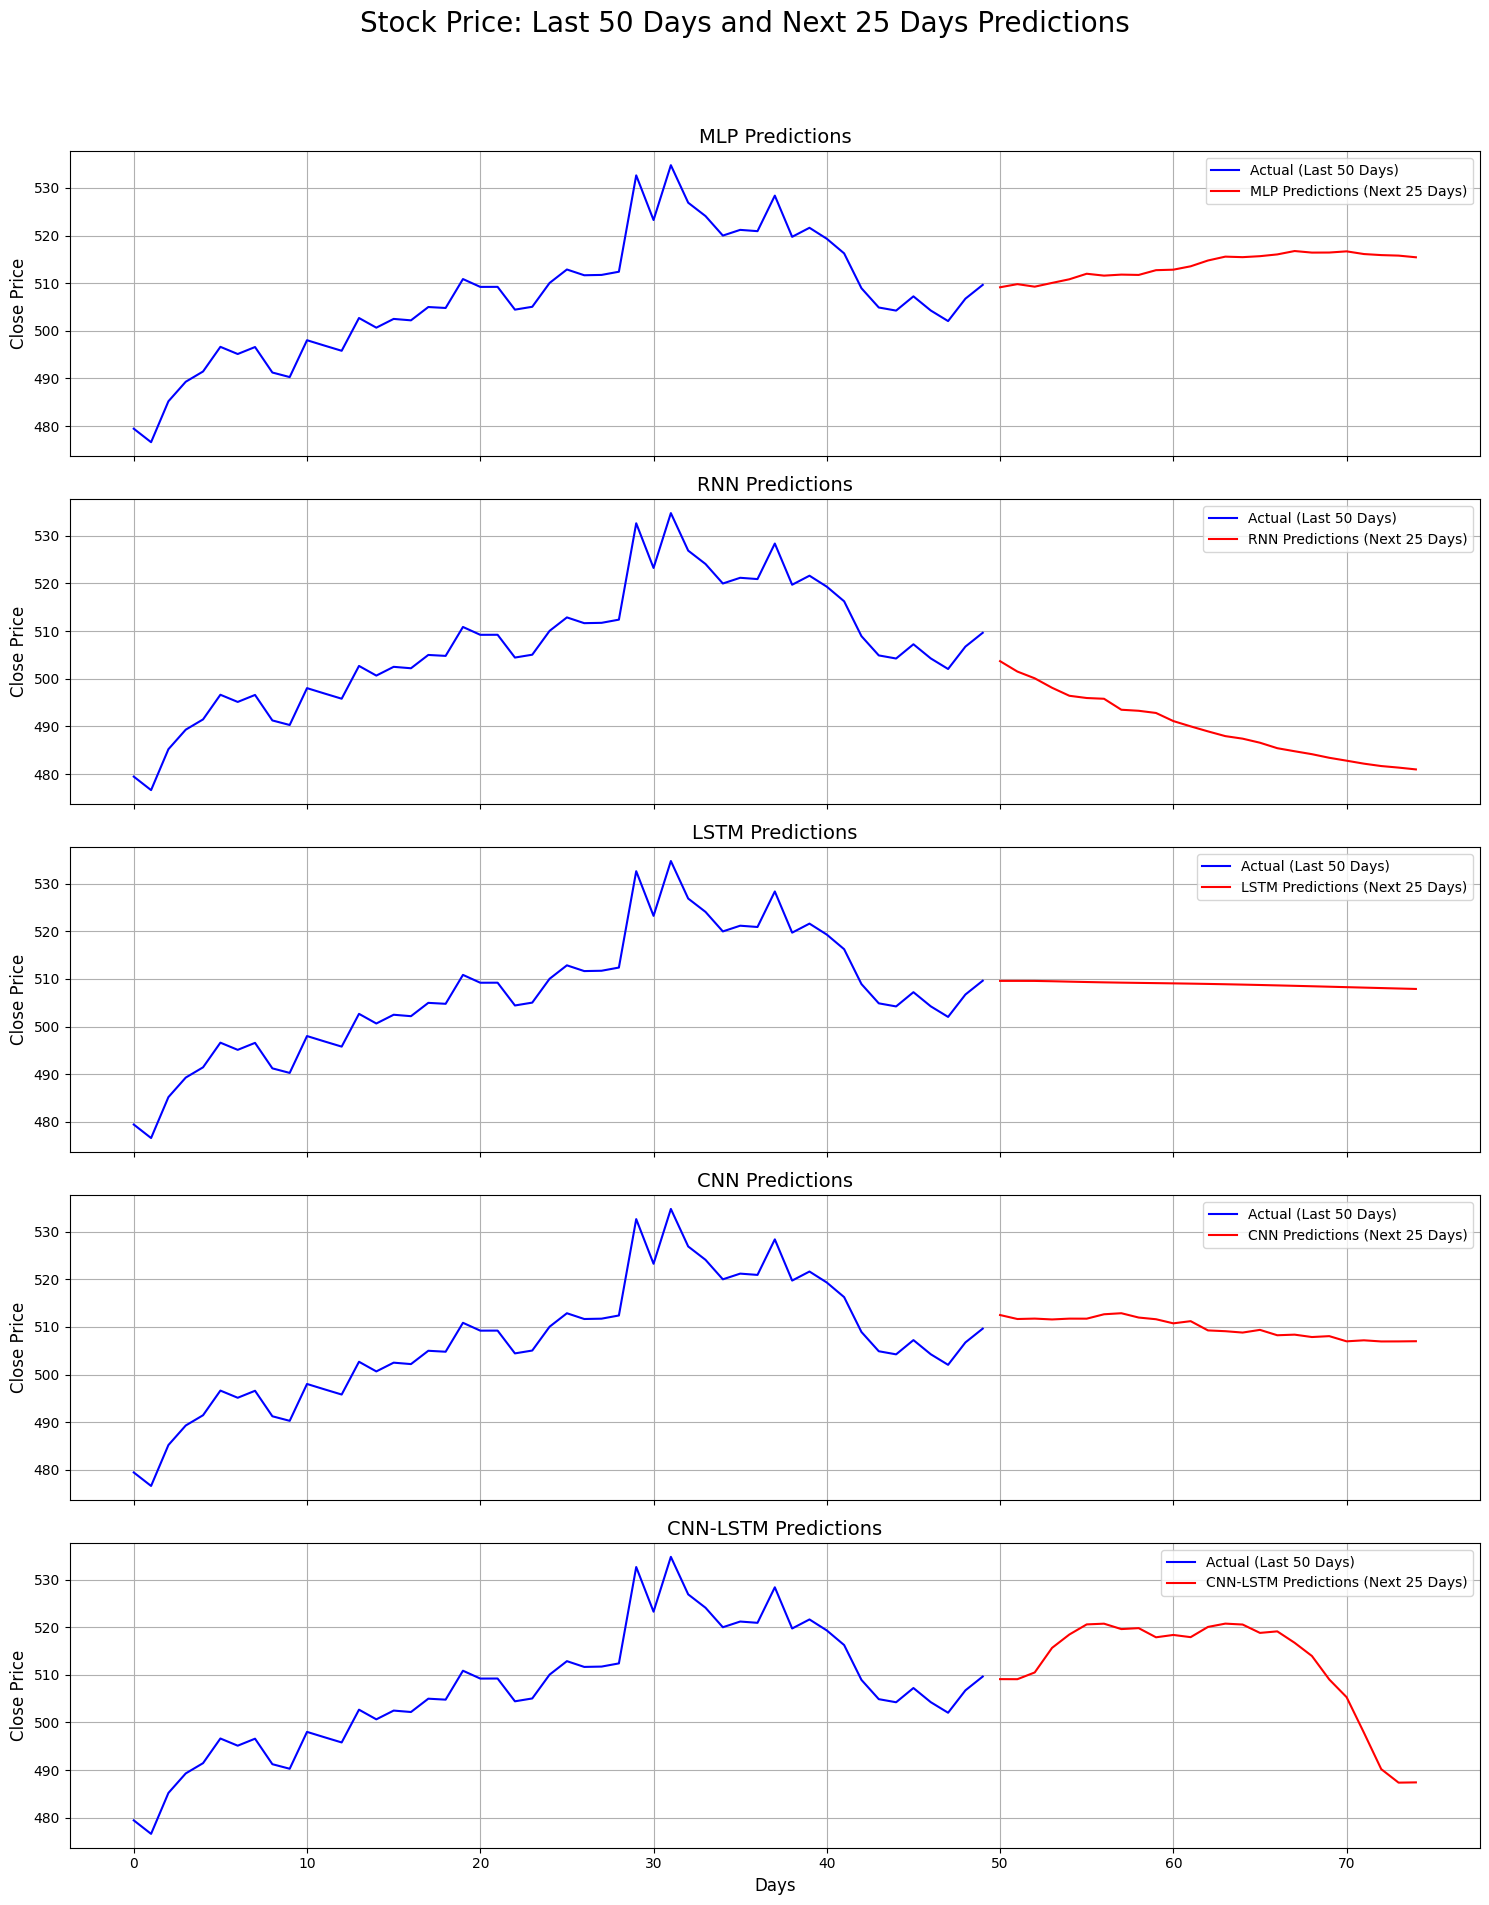

In [ ]:
# Dapatkan data aktual 25 hari terakhir
last_25_days_data = data.iloc[-time_step:].Close.values

# Buat gambar dengan 5 subplot (satu untuk setiap model)
fig, axes = plt.subplots(5, 1, figsize=(15, 20), sharex=True)
fig.suptitle('Stock Price: Last 50 Days and Next 25 Days Predictions', fontsize=20)

# Plot data aktual dan prediksi untuk setiap model
for i, (model_name, predictions) in enumerate(future_preds.items()):
    # Plot 50 hari terakhir (data aktual)
    axes[i].plot(np.arange(time_step), last_25_days_data, label='Actual (Last 50 Days)', c='b')

    # Plot prediksi masa depan mulai dari hari ke-50
    axes[i].plot(np.arange(time_step, time_step + n_future), predictions.flatten(), label=f'{model_name} Predictions (Next 25 Days)', c='r')

    axes[i].set_ylabel("Close Price", fontsize=12)
    axes[i].set_title(f"{model_name} Predictions", fontsize=14)
    axes[i].legend()
    axes[i].grid(True)

axes[-1].set_xlabel("Days", fontsize=12)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Sesuaikan tata letak untuk mencegah judul tumpang tindih
plt.show()

### Interpretasi
Berdasarkan grafik yang memperlihatkan harga saham aktual selama 50 hari terakhir (garis biru) dan prediksi 25 hari mendatang (garis merah) untuk masing-masing model, dapat diidentifikasi pola berikut:
* MLP memprediksi tren yang relatif stabil dengan sedikit kenaikan di awal periode prediksi, kemudian mendatar menuju akhir. Model ini cenderung moderat dan tidak terlalu agresif mengikuti fluktuasi masa lalu.
* RNN menunjukkan tren penurunan cukup tajam setelah awal prediksi, mengindikasikan kecenderungan model ini untuk mengekstrapolasi penurunan dari pola sebelumnya secara lebih kuat.
* LSTM menghasilkan prediksi yang hampir datar tanpa variasi berarti. Hal ini menunjukkan sifat LSTM yang fokus pada kestabilan jangka pendek, namun dengan risiko kurang menangkap potensi perubahan arah tren.
* CNN memberikan fluktuasi ringan dengan sedikit kecenderungan menurun, namun tetap lebih responsif dibanding LSTM.
* CNN-LSTM memulai prediksi dengan kenaikan yang cukup signifikan hingga pertengahan periode, kemudian mengalami penurunan yang tajam di akhir horizon. Ini menunjukkan model ini sangat sensitif terhadap pola lokal namun kurang konsisten untuk jangka waktu lebih panjang.

Secara keseluruhan, LSTM memberikan prediksi paling stabil namun kurang adaptif, RNN cenderung pesimis, dan CNN-LSTM menunjukkan perilaku yang lebih bergejolak dengan potensi overfitting. Sementara itu, MLP relatif seimbang dengan kecenderungan mendatar, dan CNN berada di tengah dengan sedikit fluktuasi namun tidak ekstrem.

# Conclusion

Proyek ini berhasil menerapkan berbagai arsitektur deep learning untuk memprediksi harga penutupan saham dengan pendekatan berbasis data historis. Setiap model menunjukkan karakteristik dan perilaku yang berbeda terhadap pola data:
* MLP berperan baik sebagai baseline dengan prediksi yang moderat, namun kurang mampu merepresentasikan dinamika temporal yang kompleks.
* RNN mampu menangkap pola urutan dengan lebih baik, tetapi cenderung memberikan prediksi yang terlalu pesimis pada horizon yang lebih panjang.
* LSTM memberikan hasil yang stabil dengan kesalahan relatif rendah, menunjukkan kemampuannya dalam mempertahankan konteks jangka panjang tanpa fluktuasi berlebihan.
* CNN dapat mengenali pola lokal dengan baik, namun prediksinya sedikit berfluktuasi dan kurang konsisten dalam tren jangka panjang.
* CNN-LSTM menggabungkan keunggulan ekstraksi fitur lokal CNN dengan pemahaman jangka panjang LSTM, namun pada kasus ini masih menunjukkan ketidakstabilan terhadap perubahan tren mendadak.

Prediksi 25 hari ke depan secara umum mengikuti arah historis, tetapi belum sepenuhnya dapat dijadikan dasar keputusan investasi tanpa mempertimbangkan faktor eksternal seperti kondisi makroekonomi, berita pasar, dan sentimen investor.

# Thank You